In [ ]:
import pyrvo2
import numpy as np
import math
from pyrvo2 import *

goals=[];
obstale_list=[(50, 50), (-50, 50), (-50, -50),(50, 50)]
def setupScenario(sim):
    sim.setTimeStep(0.1);
    sim.setAgentDefaults(15.0, 10, 10.0, 10.0, 1.5, 2.0,np.array([0,0]));
    for i in range(250):
        sim.addAgent(200.0 *np.array([math.cos(i * 2.0 * math.pi / 250.0),math.sin(i * 2.0 *  math.pi / 250.0)]))
        goals.append(-sim.getAgentPosition(i));
    sim.addObstacle(obstale_list)
    # sim.processObstacles()
        
def updateVisualization(sim):
    print(sim.getGlobalTime());
    for i in range(sim.getNumAgents()):
        print(sim.getAgentPosition())

def setPreferredVelocities( sim):
    for i in range(sim.getNumAgents()):
        goalVector = goals[i] - sim.getAgentPosition(i);
        if (np.linalg.norm(goalVector) > 1.0):
            goalVector = goalVector/np.linalg.norm(goalVector)
        sim.setAgentPrefVelocity(i, goalVector);

def reachedGoal(sim):
    for i in range(sim.getNumAgents()):
        if (np.linalg.norm(sim.getAgentPosition(i) - goals[i]) > sim.getAgentRadius(i)):
            return False;
    return True;



In [38]:
import pygame as pg
screen_size=[400,400]
world_size =[500,500]
screen=pg.display.set_mode(screen_size)
screen_size= np.array(screen_size)
screen_center = screen_size/2
world_center = np.array([0,0])
world_size = np.array(world_size)
def getScreenPos(world_pos):
    return (world_pos-world_center)/world_size*screen_size+screen_center
def getScreenRadius(radius_world):
    return radius_world/np.max(world_size)*np.max(screen_size)

def visualize(sim):
    screen.fill(pg.Color("white"))
    for i in range(sim.getNumAgents()):
        pos = getScreenPos(sim.getAgentPosition(i))
        radius = getScreenRadius(sim.getAgentRadius(i))
        pg.draw.circle(screen,pg.Color("blue"),(pos[0],pos[1]),radius,0)
        
  # Draw obstacles

    for i in range(len(obstale_list)-1):
        start_pos = getScreenPos(obstale_list[i])
        end_pos = getScreenPos(obstale_list[i+1])
        pg.draw.line(screen, pg.Color("red"), (int(start_pos[0]), int(start_pos[1])), (int(end_pos[0]), int(end_pos[1])), 2)
                
    pg.display.update()


import time
start_time = time.time()
sim = RVOSimulator();
setupScenario(sim);
sim.processObstacle()
while (not reachedGoal(sim)):
    setPreferredVelocities(sim);
    sim.step();
    visualize(sim)
end_time = time.time()
print(end_time-start_time)

KeyboardInterrupt: 

convert from $(v,w)$ to $(v_l,v_r)$


$v_r=\frac{2v+Lw}{2}$,$v_l=\frac{2v-Lw}{2}$

convert from $(v_l,v_r)$ to $(v,w)$

$v=\frac{v_l+v_r}{2}$,$w=\frac{v_r-v_l}{L}$,


<Figure size 1000x800 with 0 Axes>

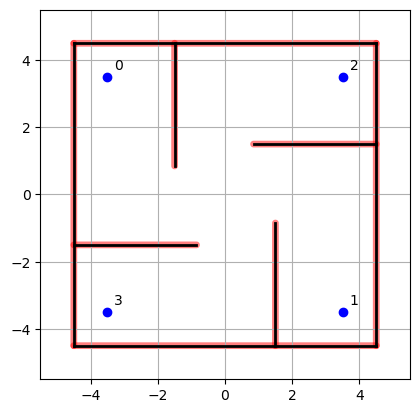

In [ ]:
from SimEnv import get_edges,SimulationEnvironment_Scenario2,SimulationEnvironment_Scenario6,\
SimulationEnvironment_CubeCollection,SimulationEnvironment_Warehouse,SimulationEnvironment_CA
env= SimulationEnvironment_CA()
from shapely.geometry import Polygon, Point,LineString

plt.figure(figsize=(10, 8))
env.display_environment(show=0)

for line in env.lines:
    for i in range(len(line)-1):
        edge=[line[i],line[i+1]]
        line_segment_buffer = LineString(edge).buffer(0.1)
        x, y = line_segment_buffer.exterior.xy
        plt.fill(x, y, alpha=0.5, fc='r', ec='none', label='Buffer')

for obstacle in env.obstacles:
    edge=get_edges(list(obstacle.exterior.coords))
    x=[seg[0] for seg in edge]
    y=[seg[1] for seg in edge]
    plt.fill(x, y, alpha=0.5, fc='r', ec='none', label='Buffer')
    
plt.show()
# env.display_environment()

In [6]:
from offpolicy.envs.lasercar.env_core import EnvCore

# Create a parameters class to hold all the required arguments
# @dataclass
class Args:
    num_sensors: int = 16
    Car_resettype: str = "diag"  # Options: "random_target", "diag"
    num_agents: int = 4
    turnoff_sensor: bool = False
    add_sensor_noise: bool = True
    fixed_theta: bool = True
    scenario: str = "CA"  # Use an available scenario
    share_reward: bool = False
    sensor_gussian_noise: float = 0.1
    save_history: bool = True
    plot_traj: bool = True
    traj_hold: bool = True
    plot_sensor_line: bool = True
    ifi: float = 0.1  # Animation interval
# Set up the parameters
args = Args()

# Create the environment
env = EnvCore(args)
env.seed(42)  # For reproducibility

# Reset the environment
observations = env.reset()

/usr/local/lib/python3.10/dist-packages/gym/spaces/box.py:73: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(


In [ ]:
import pyrvo2
import numpy as np
import math
from pyrvo2 import *
import pygame as pg
import time
from SimEnv import get_edges,SimulationEnvironment_Scenario2,SimulationEnvironment_Scenario6,\
SimulationEnvironment_CubeCollection,SimulationEnvironment_Warehouse,SimulationEnvironment_CA
from shapely.geometry import Polygon, Point,LineString


obstale_lists=[]
obstale_list=[]
for line in env.SimEnv.lines:
    for i in range(len(line)-1):
        edge=[line[i],line[i+1]]
        line_segment_buffer = LineString(edge).buffer(0.05)
        x, y = line_segment_buffer.exterior.xy
        obstale_lists.append([(x[j],y[j]) for j in range(len(x))])
for obstacle in env.SimEnv.obstacles:
    edge=get_edges(list(obstacle.exterior.coords))
    # print(edge)
    obstale_list=[(seg[0],seg[1]) for seg in edge]
    obstale_list.append((edge[-1][2],edge[-1][3]))
    obstale_lists.append(obstale_list)
    # x=[seg[0] for seg in edge]
    # y=[seg[1] for seg in edge]
    # plt.fill(x, y, alpha=0.5, fc='r', ec='none', label='Buffer')
print(f"obstacle num {len(obstale_lists)}")

def setupScenario(sim):
    goals=[]
    sim.setTimeStep(0.1);
    #(float neighborDist, size_t maxNeighbors,
    #   float timeHorizon, float timeHorizonObst,
    #   float radius, float maxSpeed,
    #    Eigen::Vector2f &velocity);
    sim.setAgentDefaults(neighborDist=5, maxNeighbors=32, timeHorizon=5.0, timeHorizonObst=1.0, radius=0.2, maxSpeed=1.0, velocity=np.array([0,0]));#Unmaze
    for car in env.cars:
        sim.addAgent(np.array([car['x'],car['y']]))
        goals.append(np.array([car['goal_x'],car['goal_y']]));
    for obstale_list in obstale_lists:
        sim.addObstacle(obstale_list)
    sim.processObstacle()
    return goals
   
def updateVisualization(sim):
    print(sim.getGlobalTime());
    for i in range(sim.getNumAgents()):
        print(sim.getAgentPosition())

def setPreferredVelocities( sim,goals):
    for i in range(sim.getNumAgents()):
        goalVector = goals[i] - sim.getAgentPosition(i);
        if (np.linalg.norm(goalVector) > 1.0):
            goalVector = goalVector/np.linalg.norm(goalVector)
        sim.setAgentPrefVelocity(i, goalVector);

def reachedGoal(sim,goals):
    # print(goals)
    for i in range(sim.getNumAgents()):
        if (np.linalg.norm(sim.getAgentPosition(i) - goals[i]) > sim.getAgentRadius(i)):
            # print(sim.getAgentPosition(i),np.linalg.norm(sim.getAgentPosition(i) - goals[i]))
            return False;
    return True;

screen_size=[400,400]
world_size =[20,20]
screen=pg.display.set_mode(screen_size)
screen_size= np.array(screen_size)
screen_center = screen_size/2
world_center = np.array([0,0])
world_size = np.array(world_size)
def getScreenPos(world_pos):
    return (world_pos-world_center)/world_size*screen_size+screen_center
def getScreenRadius(radius_world):
    return radius_world/np.max(world_size)*np.max(screen_size)

def visualize(sim):
    screen.fill(pg.Color("white"))
    for i in range(sim.getNumAgents()):
        pos = getScreenPos(sim.getAgentPosition(i))
        radius = getScreenRadius(sim.getAgentRadius(i))
        pg.draw.circle(screen,pg.Color("blue"),(pos[0],pos[1]),radius,0)
        
  # Draw obstacles
    for obstale_list in obstale_lists:
        for i in range(len(obstale_list)-1):
            start_pos = getScreenPos(obstale_list[i])
            end_pos = getScreenPos(obstale_list[i+1])
            pg.draw.line(screen, pg.Color("red"), (int(start_pos[0]), int(start_pos[1])), (int(end_pos[0]), int(end_pos[1])), 2)
                
    pg.display.update()


start_time = time.time()
sim = RVOSimulator();
goals=setupScenario(sim);
while (not reachedGoal(sim,goals)):
    setPreferredVelocities(sim,goals);
    sim.step();
    time.sleep(0.1)
    visualize(sim)

# end_time = time.time()
# print(end_time-start_time)
pg.quit()

obstacle num 8


KeyboardInterrupt: 

In [ ]:
import pyrvo2
import numpy as np
import math
from pyrvo2 import *
import matplotlib.pyplot as plt
from SimEnv import get_edges,SimulationEnvironment_Scenario2,SimulationEnvironment_Scenario6,\
SimulationEnvironment_CubeCollection,SimulationEnvironment_Warehouse,SimulationEnvironment_CA
from shapely.geometry import Polygon, Point,LineString

# Assuming env is defined somewhere above, like:
# env = SimulationEnvironment_Scenario2()  # or whichever scenario you're using

obstale_lists=[]
obstale_list=[]
for line in env.SimEnv.lines:
    for i in range(len(line)-1):
        edge=[line[i],line[i+1]]
        line_segment_buffer = LineString(edge).buffer(0.05)
        x, y = line_segment_buffer.exterior.xy
        obstale_lists.append([(x[j],y[j]) for j in range(len(x))])
for obstacle in env.SimEnv.obstacles:
    edge=get_edges(list(obstacle.exterior.coords))
    obstale_list=[(seg[0],seg[1]) for seg in edge]
    obstale_list.append((edge[-1][2],edge[-1][3]))
    obstale_lists.append(obstale_list)
print(f"obstacle num {len(obstale_lists)}")

def setupScenario(sim):
    goals=[]
    sim.setTimeStep(0.1)
    sim.setAgentDefaults(neighborDist=5, maxNeighbors=32, timeHorizon=5.0, timeHorizonObst=1.0, radius=0.2, maxSpeed=1.0, velocity=np.array([0,0]))
    for car in env.cars:
        sim.addAgent(np.array([car['x'],car['y']]))
        goals.append(np.array([car['goal_x'],car['goal_y']]))
    for obstale_list in obstale_lists:
        sim.addObstacle(obstale_list)
    sim.processObstacle()
    return goals

def setPreferredVelocities(sim, goals):
    for i in range(sim.getNumAgents()):
        goalVector = goals[i] - sim.getAgentPosition(i)
        if (np.linalg.norm(goalVector) > 1.0):
            goalVector = goalVector/np.linalg.norm(goalVector)
        sim.setAgentPrefVelocity(i, goalVector)

def reachedGoal(sim, goals):
    for i in range(sim.getNumAgents()):
        if (np.linalg.norm(sim.getAgentPosition(i) - goals[i]) > sim.getAgentRadius(i)):
            return False
    return True

def visualize(sim):
    plt.clf()  # Clear the previous frame
    
    # Plot agents
    for i in range(sim.getNumAgents()):
        pos = sim.getAgentPosition(i)
        radius = sim.getAgentRadius(i)
        circle = plt.Circle((pos[0], pos[1]), radius, color='blue', alpha=0.5)
        plt.gca().add_artist(circle)
    
    # Plot obstacles
    for obstale_list in obstale_lists:
        x = [point[0] for point in obstale_list]
        y = [point[1] for point in obstale_list]
        plt.plot(x, y, 'r-', linewidth=2)
        # Close the obstacle shape
        plt.plot([x[-1], x[0]], [y[-1], y[0]], 'r-', linewidth=2)
    
    # Set plot limits (equivalent to your world_size)
    plt.xlim(-10, 10)  # Adjust based on your world_size
    plt.ylim(-10, 10)  # Adjust based on your world_size
    plt.axis('equal')  # Equal aspect ratio
    plt.grid(True)
    # plt.title(f"Simulation Time: {sim.getGlobalTime():.1f}")
    
    plt.pause(0.1)  # Pause to show the animation

# Initialize the plot
plt.ion()  # Turn on interactive mode
fig = plt.figure(figsize=(8, 8))

start_time = time.time()
sim = RVOSimulator()
goals = setupScenario(sim)

while not reachedGoal(sim, goals):
    setPreferredVelocities(sim, goals)
    sim.step()
    visualize(sim)

plt.ioff()  # Turn off interactive mode
plt.show()  # Keep the final frame visible

AttributeError: 'SimulationEnvironment_Scenario2' object has no attribute 'SimEnv'

Rectangle corners: [(0.8500000000000001, 1.5), (4.5, 1.5), (4.5, 1.55), (0.8500000000000001, 1.55)]


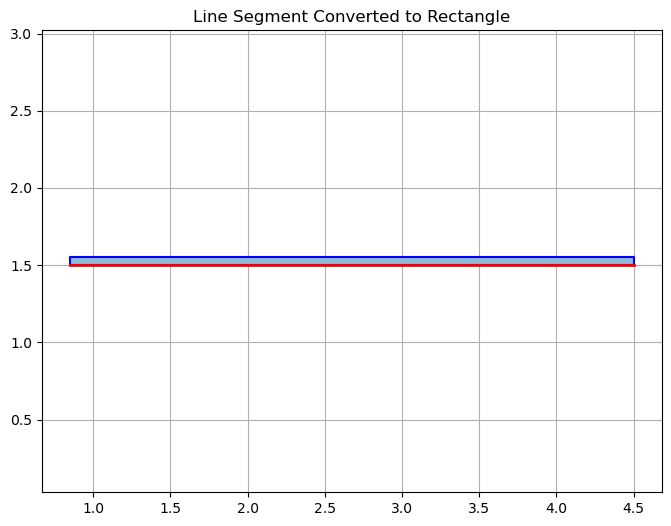

In [9]:
import numpy as np
from shapely.geometry import Polygon

def line_to_rectangle(line_segment, width):
    """
    Convert a line segment to a rectangle with specified width
    
    Parameters:
    - line_segment: List of two points [(x1, y1), (x2, y2)]
    - width: Width of the rectangle perpendicular to the line segment
    
    Returns:
    - Rectangle as a list of four corner points in counter-clockwise order
    """
    # Extract points
    p1, p2 = line_segment
    
    # Get the direction vector of the line segment
    direction = np.array(p2) - np.array(p1)
    
    # Get the perpendicular vector (rotate 90 degrees)
    # For a 2D vector (x, y), perpendicular is (-y, x) or (y, -x)
    perpendicular = np.array([-direction[1], direction[0]])
    
    # Normalize perpendicular vector and scale to desired width
    if np.linalg.norm(perpendicular) > 0:
        perpendicular = perpendicular / np.linalg.norm(perpendicular) * width
    else:
        perpendicular = np.array([0, width])
    
    # Calculate the four corners of the rectangle
    corners = [
        p1,
        p2,
        tuple(np.array(p2) + perpendicular),
        tuple(np.array(p1) + perpendicular)
    ]
    
    return corners

# Example usage with your line segment
wall_len = 3.65
line_segment = [(4.5-wall_len, 1.5), (4.5, 1.5)]
width = 0.05  # Width of the rectangle

rectangle = line_to_rectangle(line_segment, width)
print("Rectangle corners:", rectangle)

# Create a Shapely polygon from the rectangle points
polygon = Polygon(rectangle)

# Example visualization
import matplotlib.pyplot as plt
x, y = polygon.exterior.xy
plt.figure(figsize=(8, 6))
plt.plot(x, y, 'b-')
plt.fill(x, y, alpha=0.5)
plt.plot([line_segment[0][0], line_segment[1][0]], 
         [line_segment[0][1], line_segment[1][1]], 'r-', linewidth=2)
plt.axis('equal')
plt.grid(True)
plt.title('Line Segment Converted to Rectangle')
plt.show()
    

[[(-1.8, 5.95), (-1.8, 0.9500000000000002), (-1.75, 0.9500000000000002), (-1.75, 5.95)], [(1.8, 5.95), (1.8, 0.9500000000000002), (1.85, 0.9500000000000002), (1.85, 5.95)], [(-1.8, -0.9500000000000002), (-1.8, -5.95), (-1.75, -5.95), (-1.75, -0.9500000000000002)], [(1.8, -0.9500000000000002), (1.8, -5.95), (1.85, -5.95), (1.85, -0.9500000000000002)], [(1.8500000000000005, 3.4), (7.45, 3.4), (7.45, 3.4499999999999997), (1.8500000000000005, 3.4499999999999997)], [(-7.45, 3.4), (-1.8500000000000005, 3.4), (-1.8500000000000005, 3.4499999999999997), (-7.45, 3.4499999999999997)], [(1.8500000000000005, -3.4), (7.45, -3.4), (7.45, -3.35), (1.8500000000000005, -3.35)], [(-7.45, -3.4), (-1.8500000000000005, -3.4), (-1.8500000000000005, -3.35), (-7.45, -3.35)], [(10.0, 10.0), (10.0, -10.0), (-10.0, -10.0), (-10.0, 10.0)]]


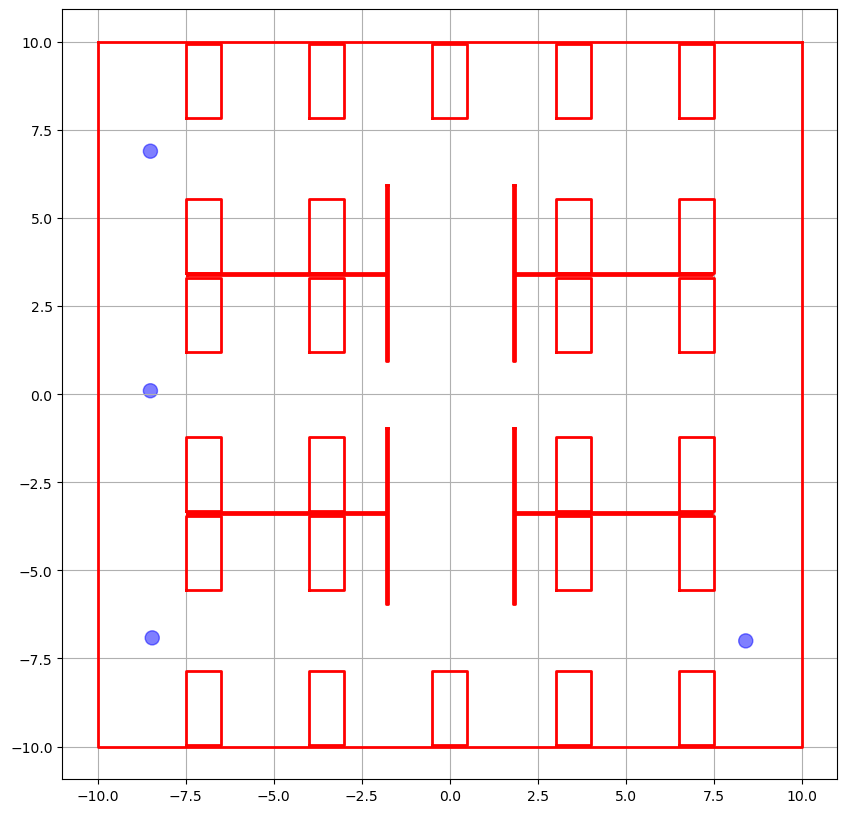

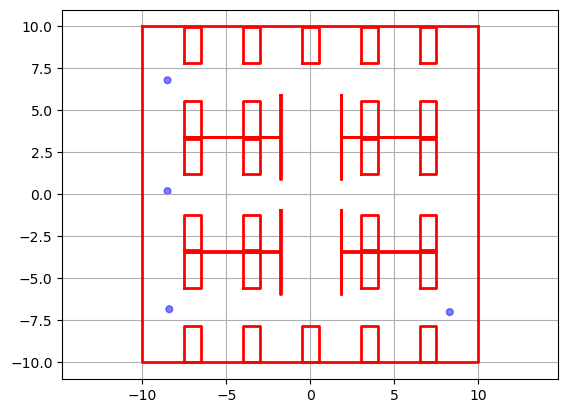

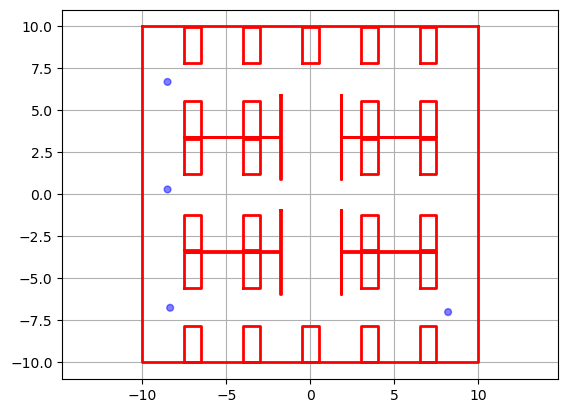

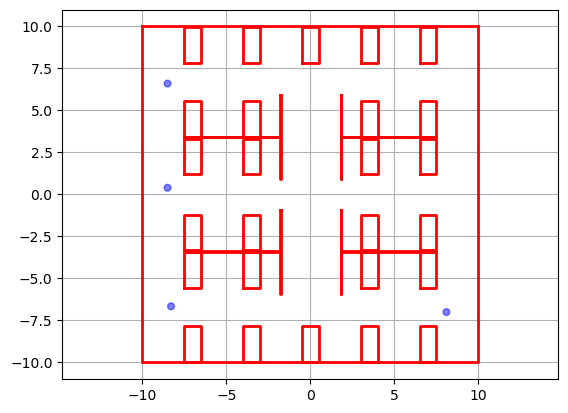

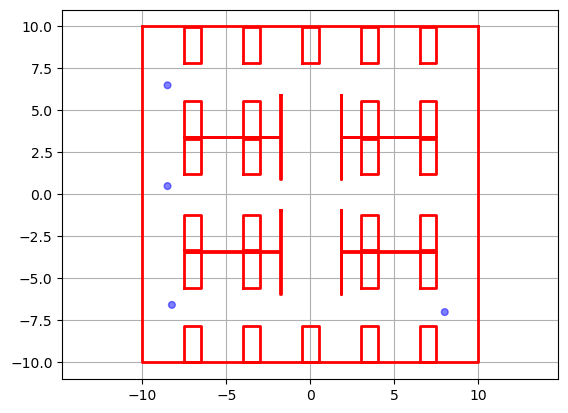

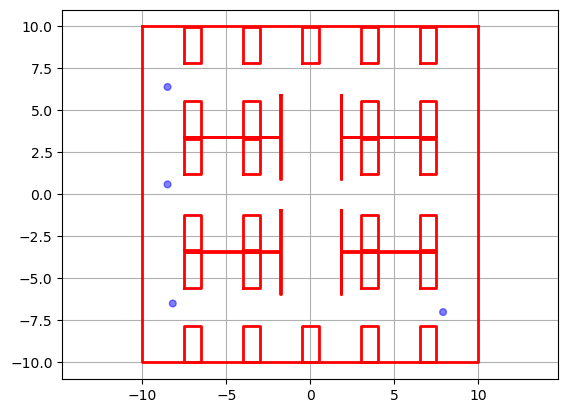

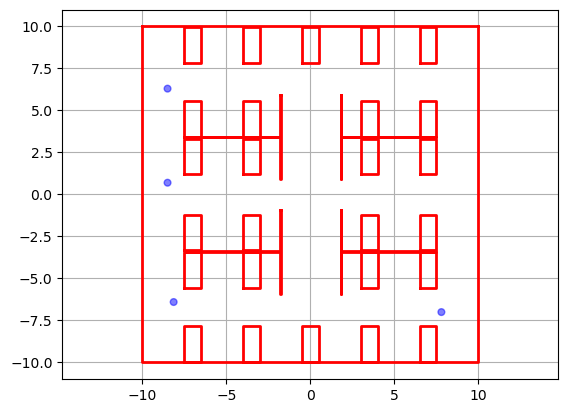

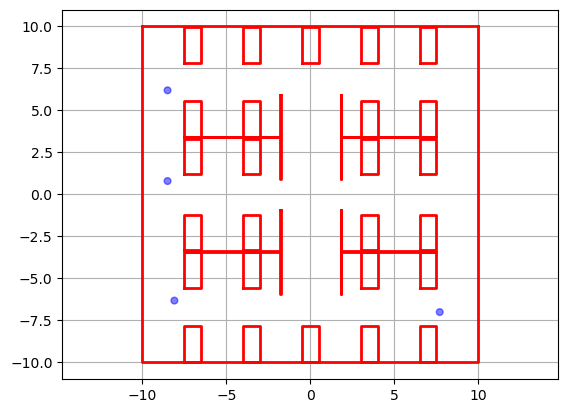

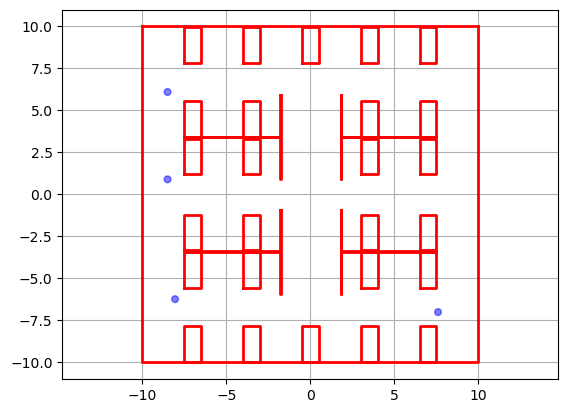

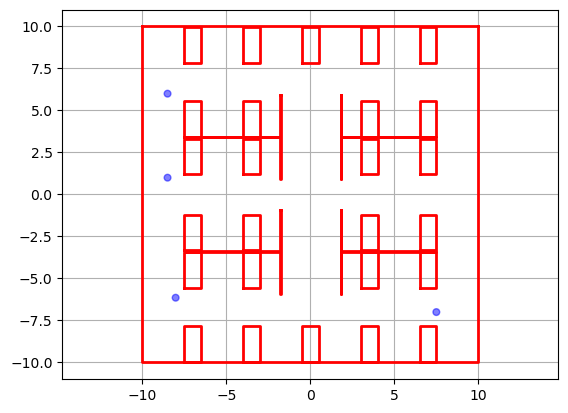

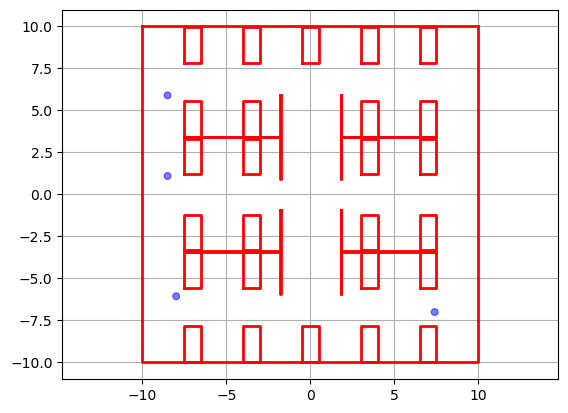

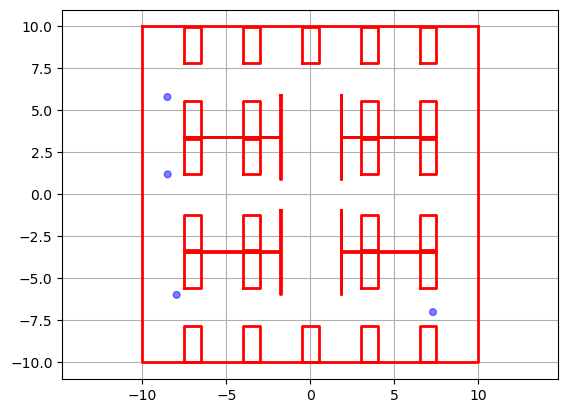

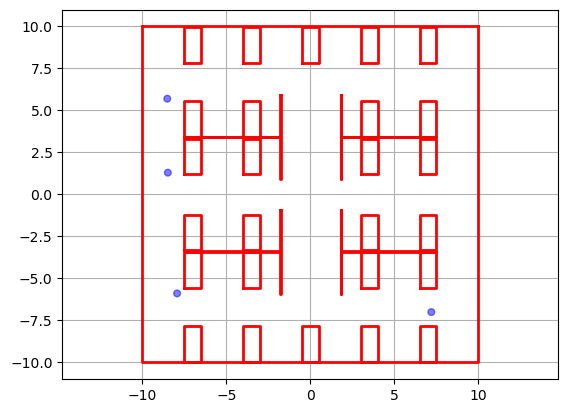

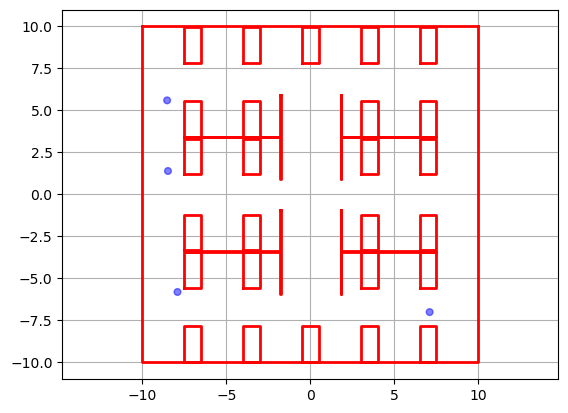

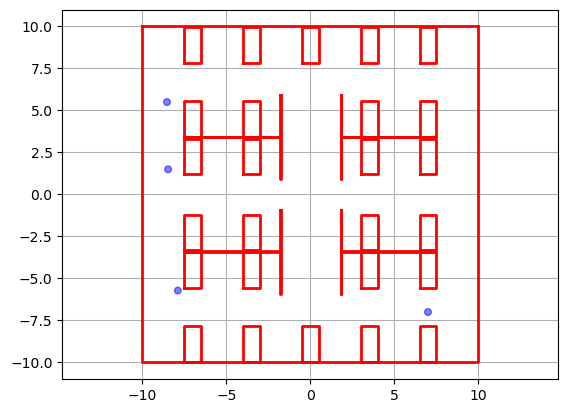

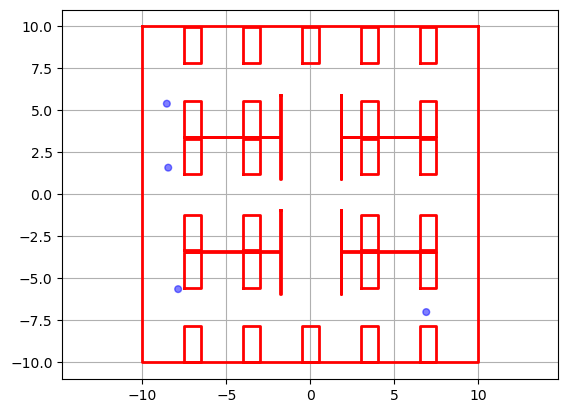

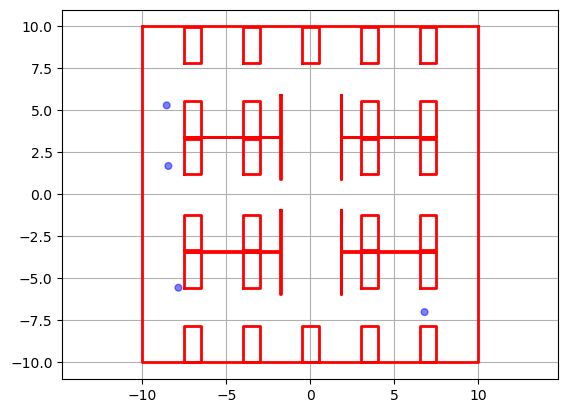

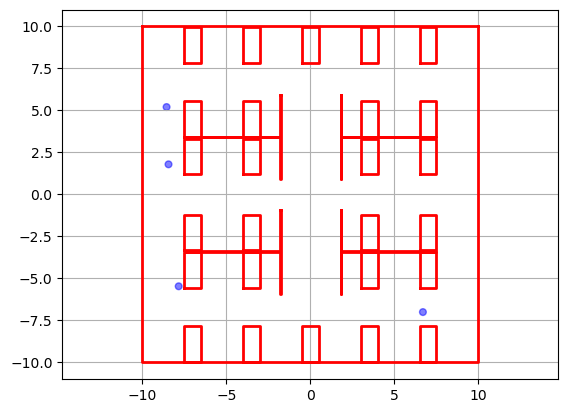

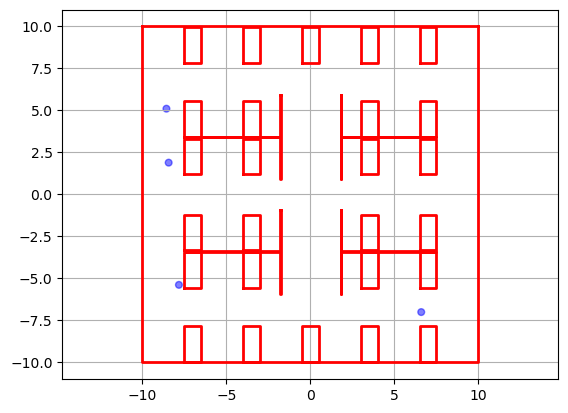

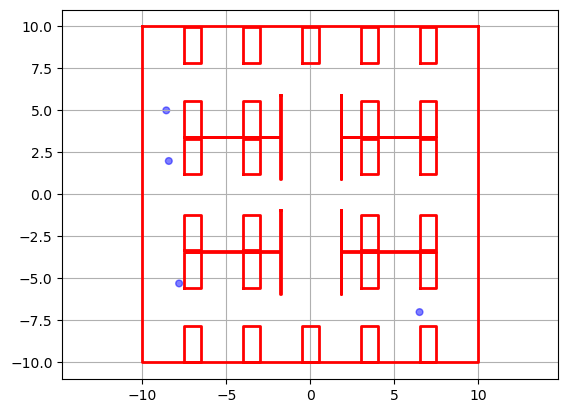

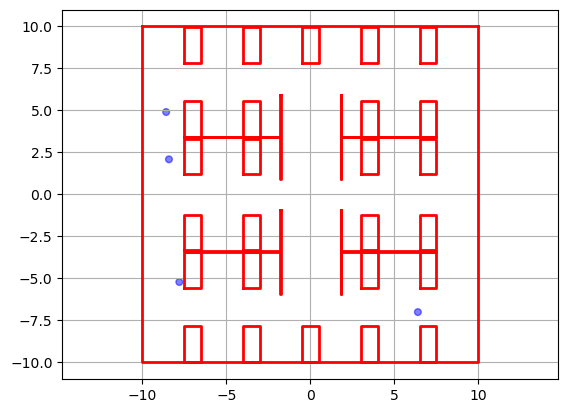

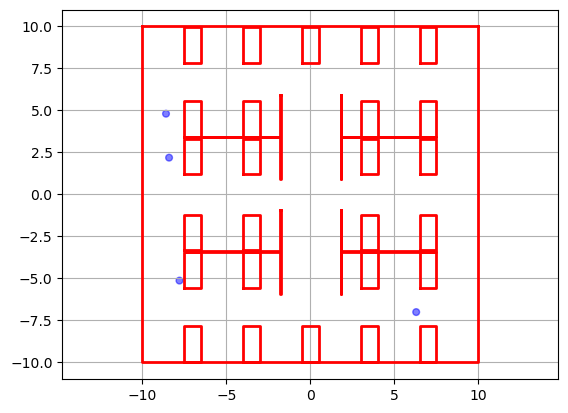

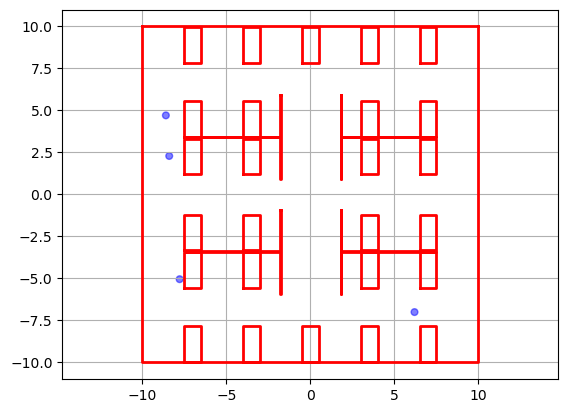

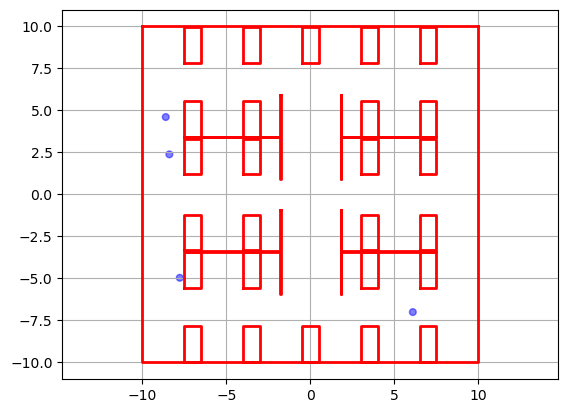

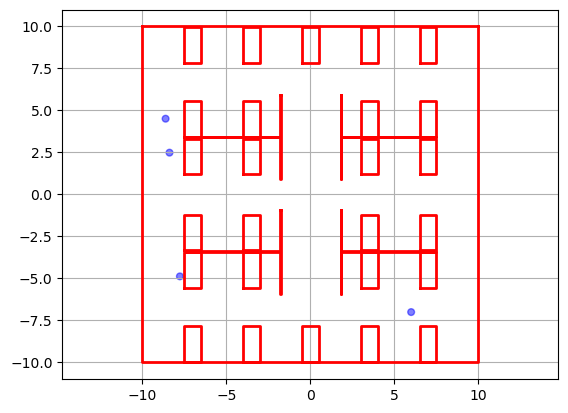

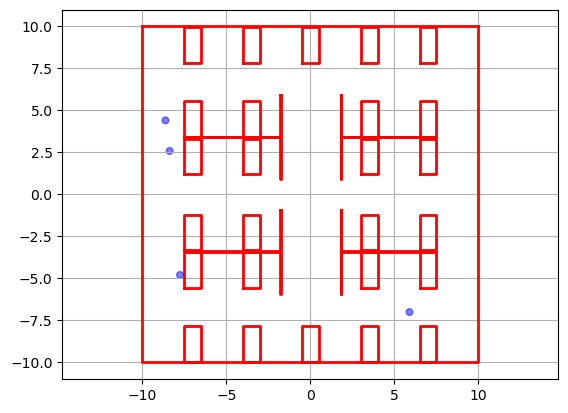

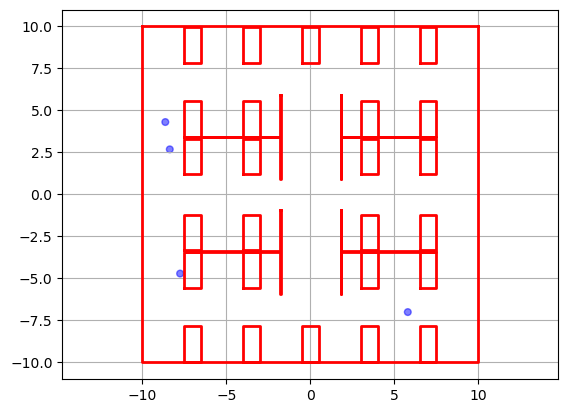

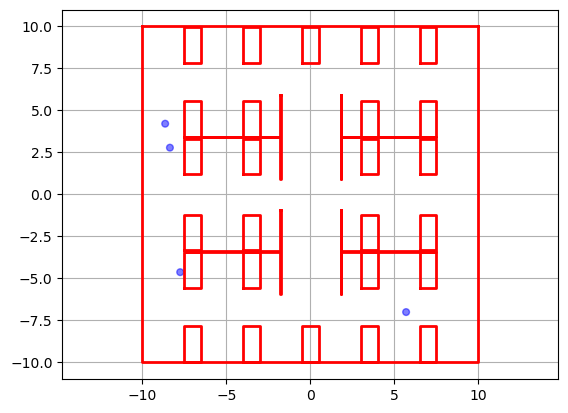

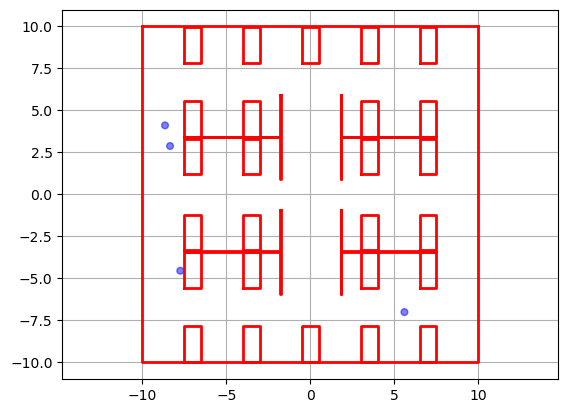

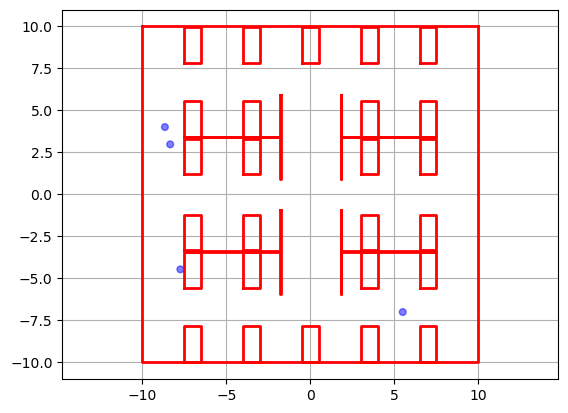

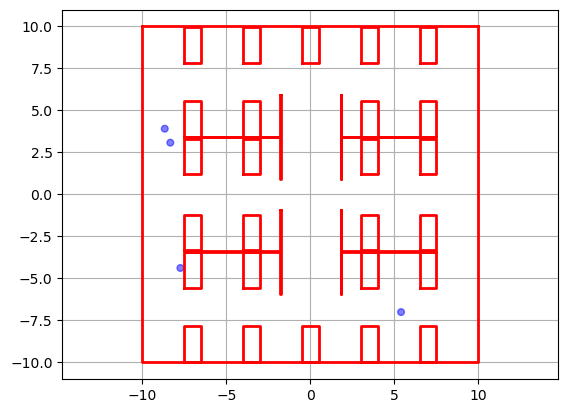

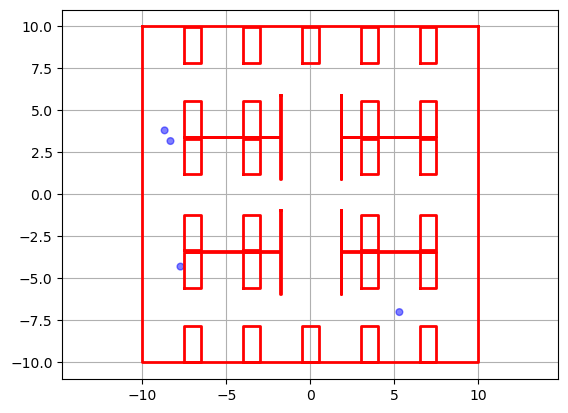

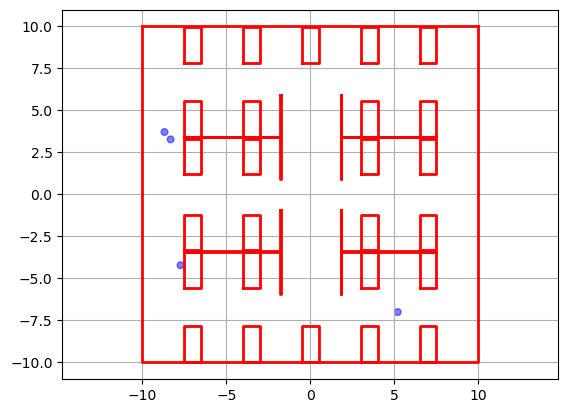

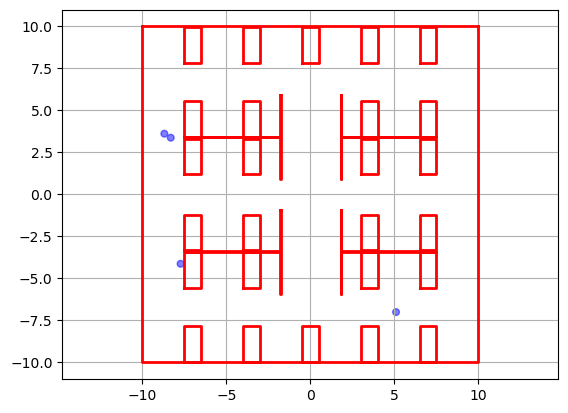

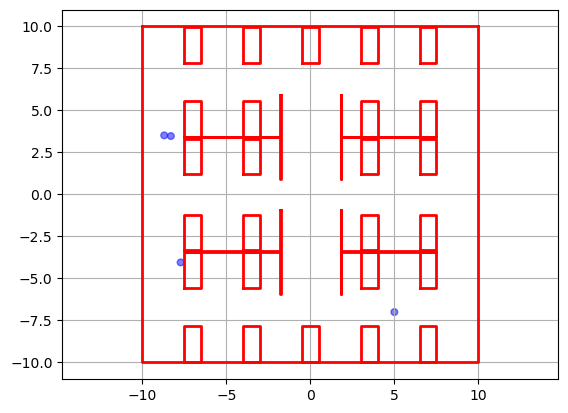

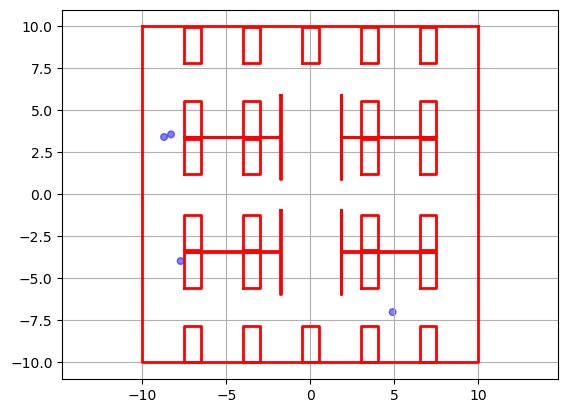

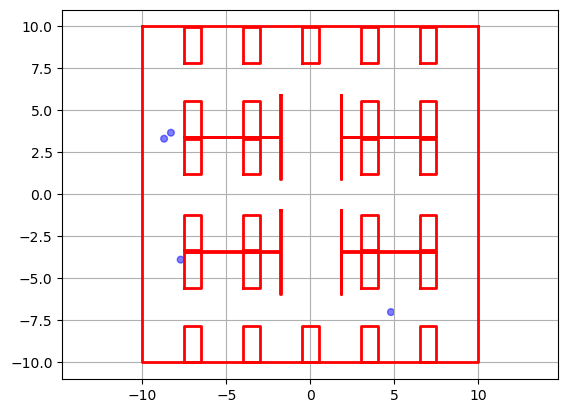

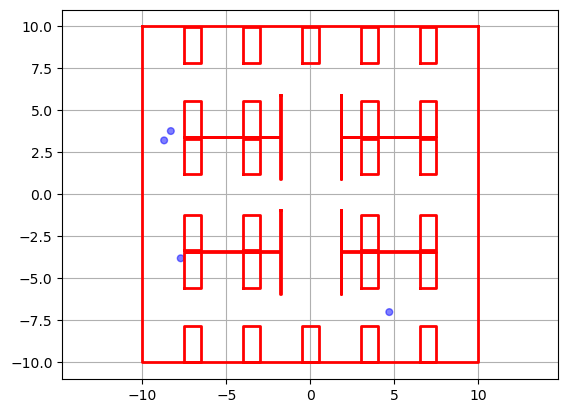

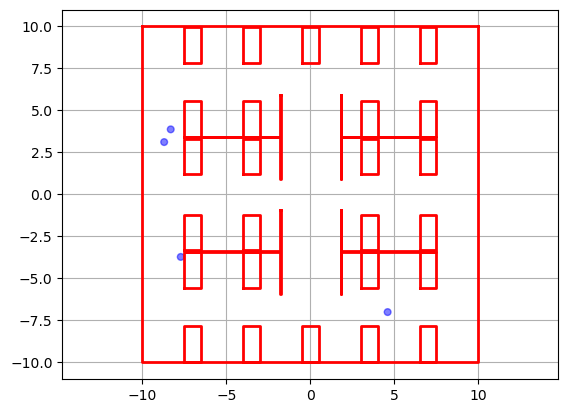

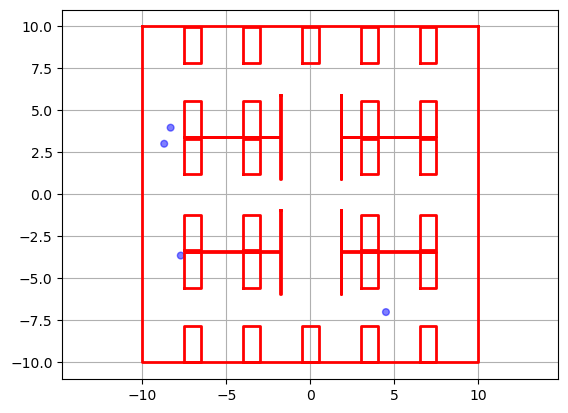

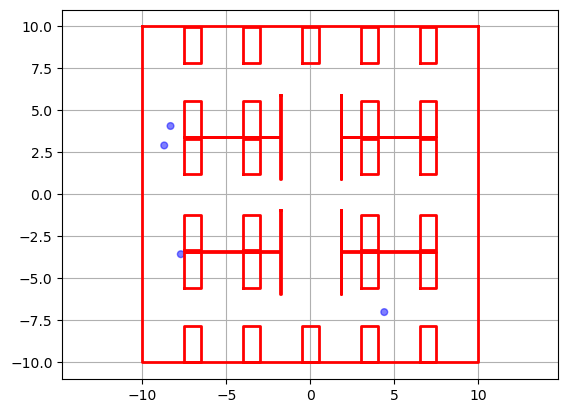

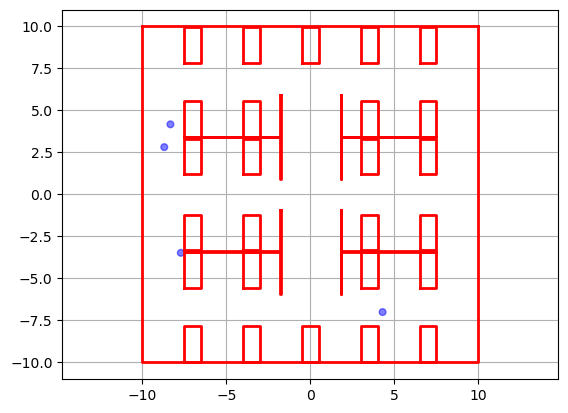

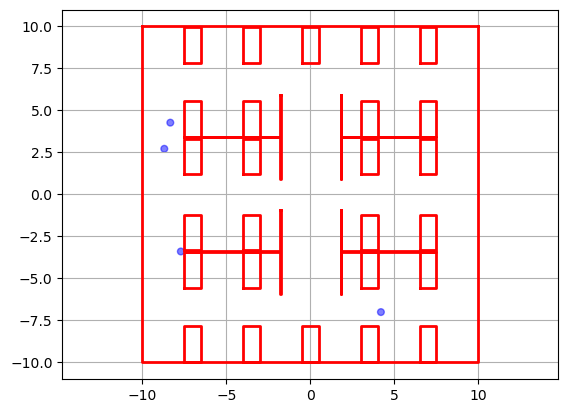

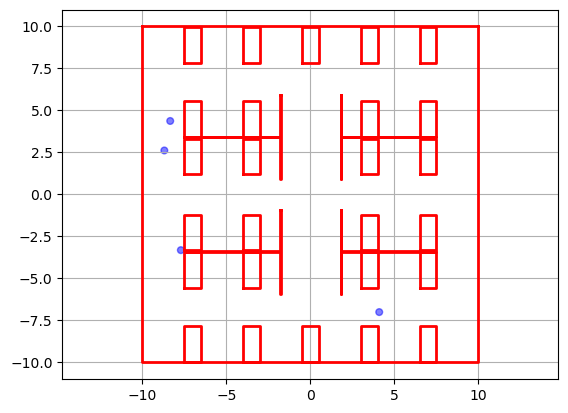

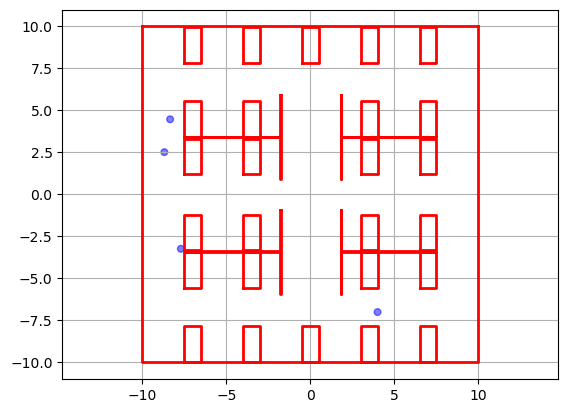

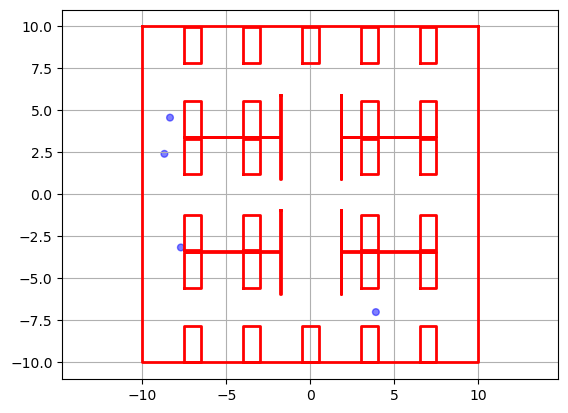

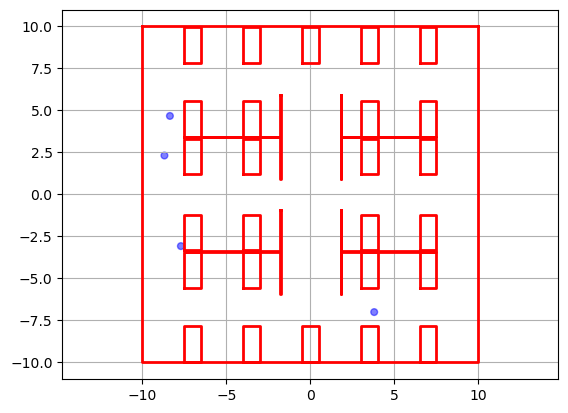

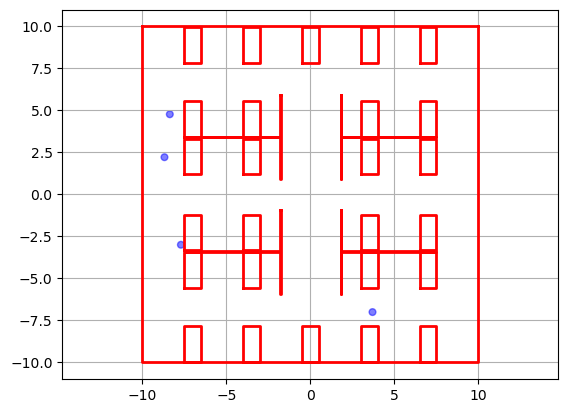

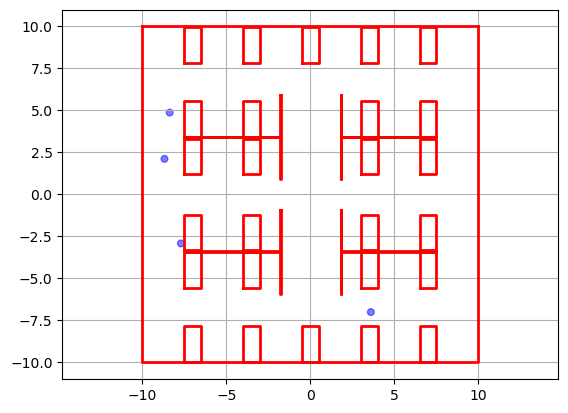

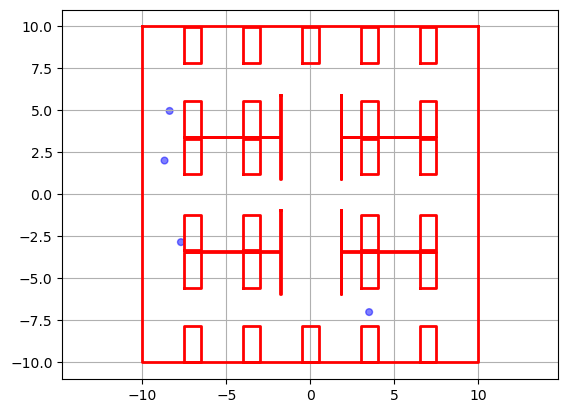

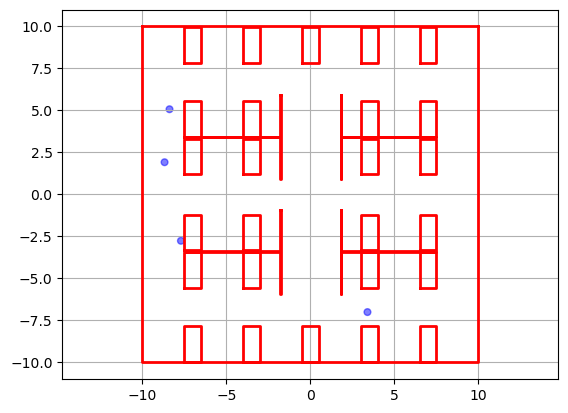

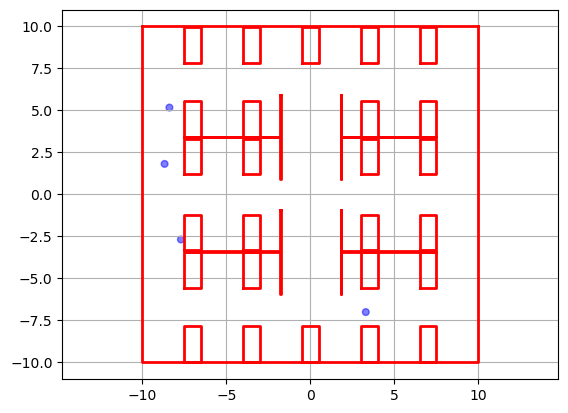

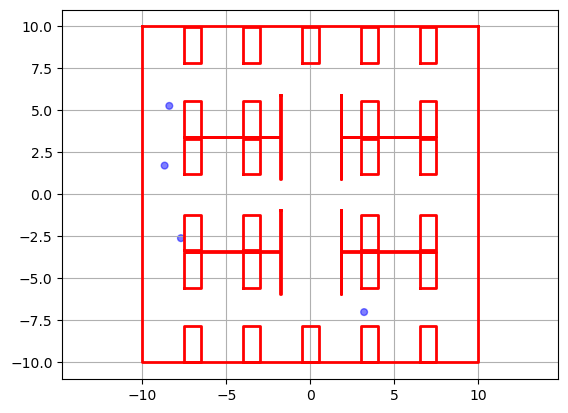

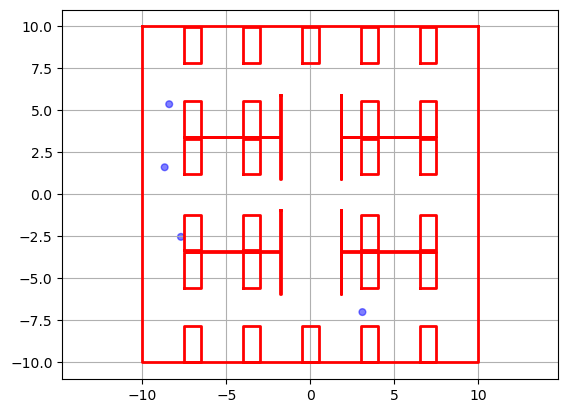

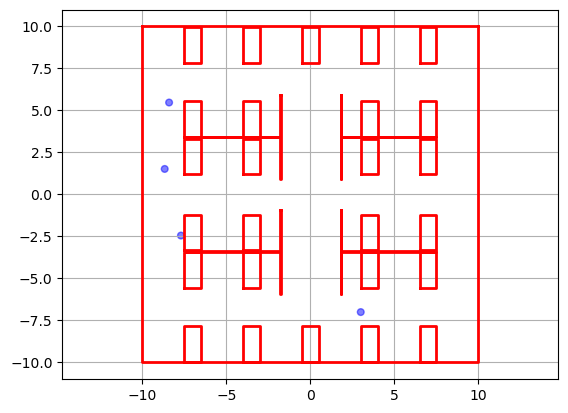

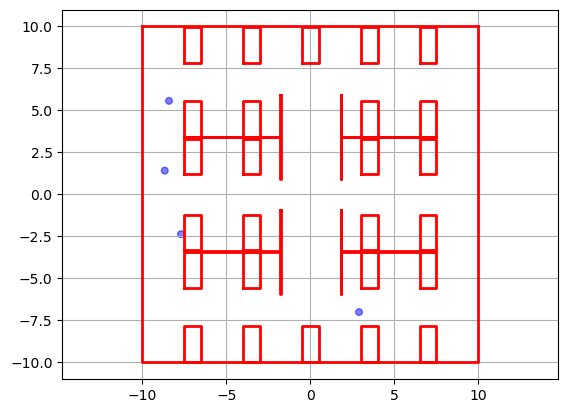

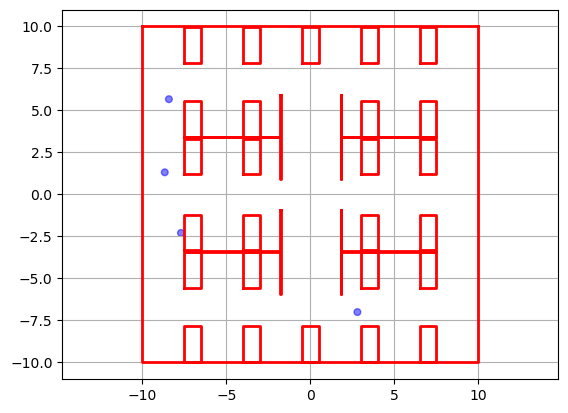

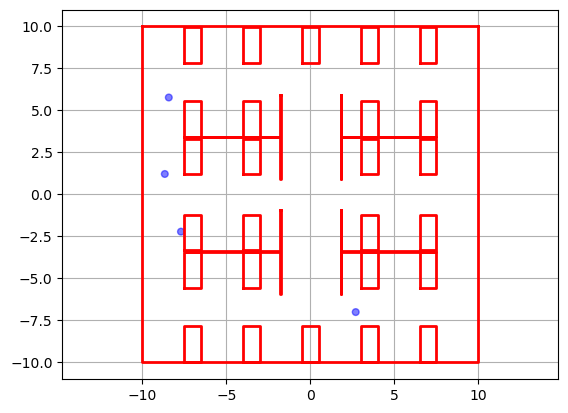

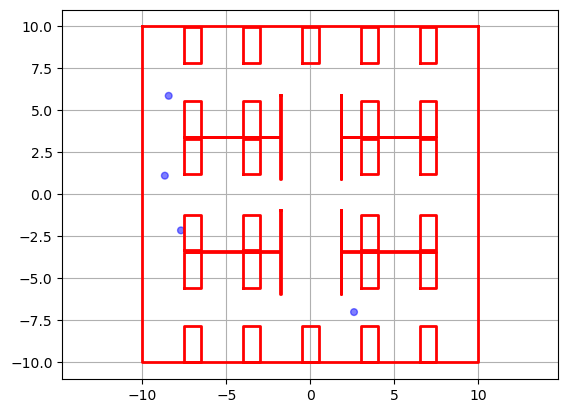

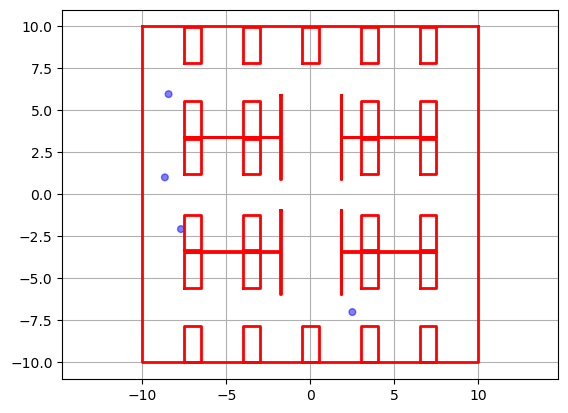

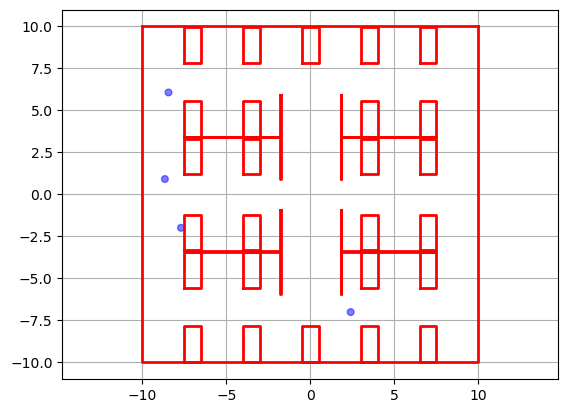

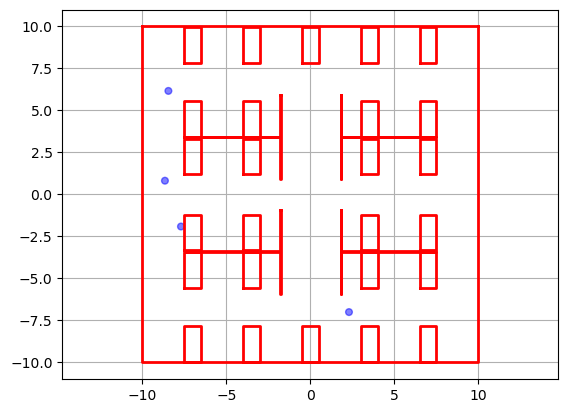

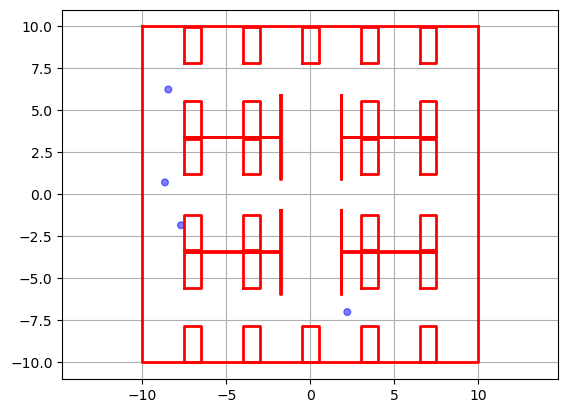

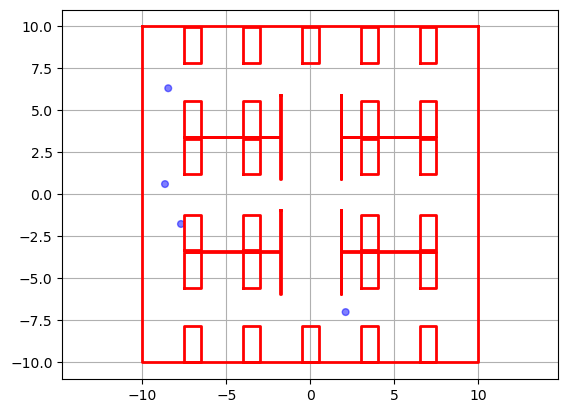

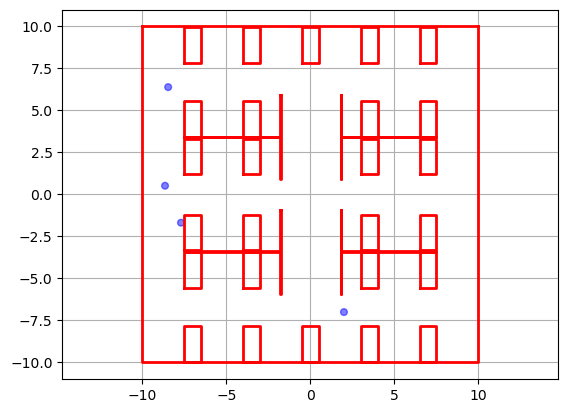

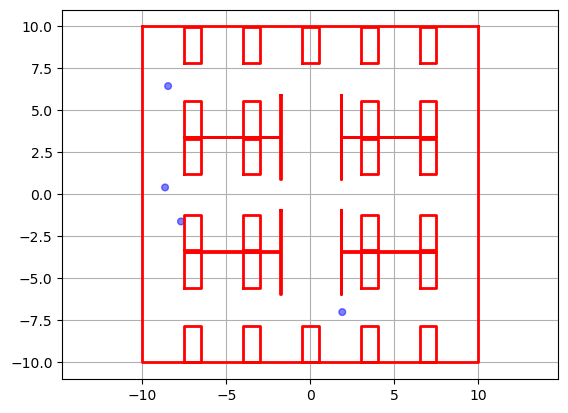

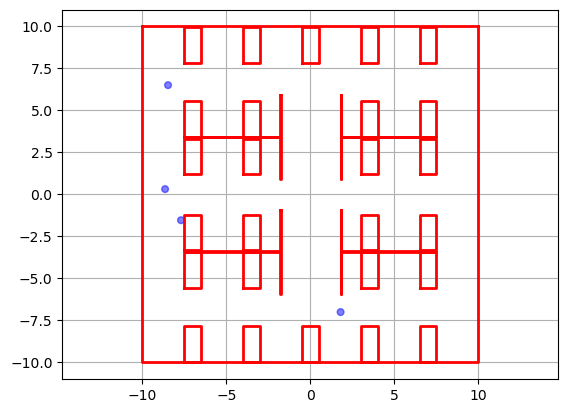

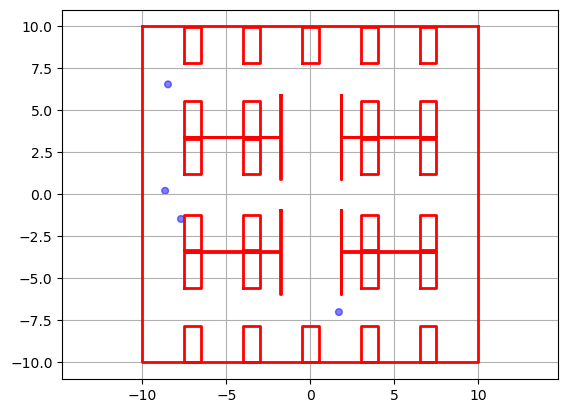

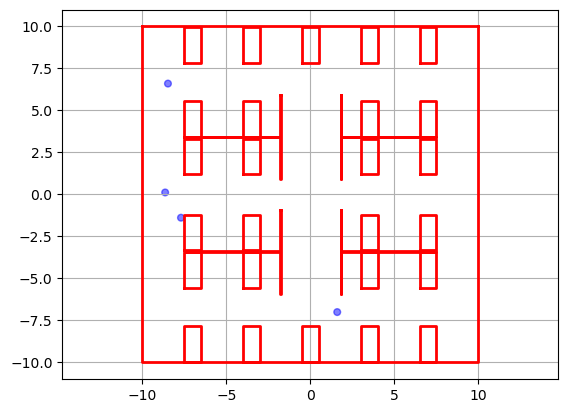

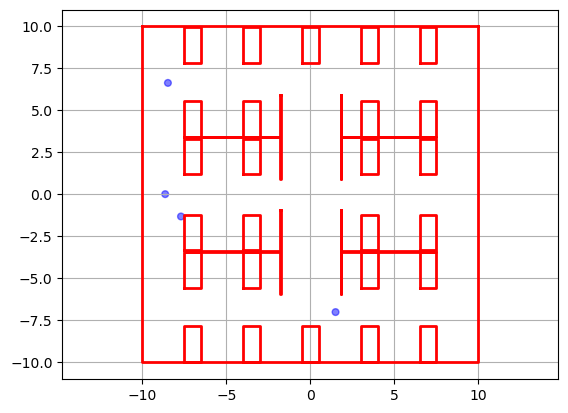

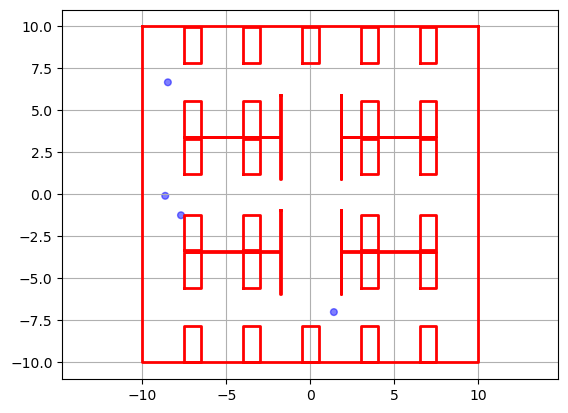

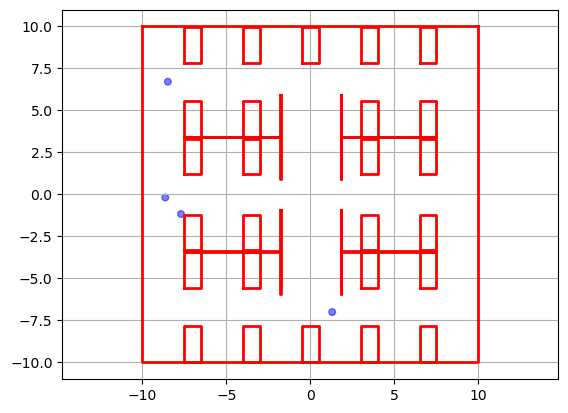

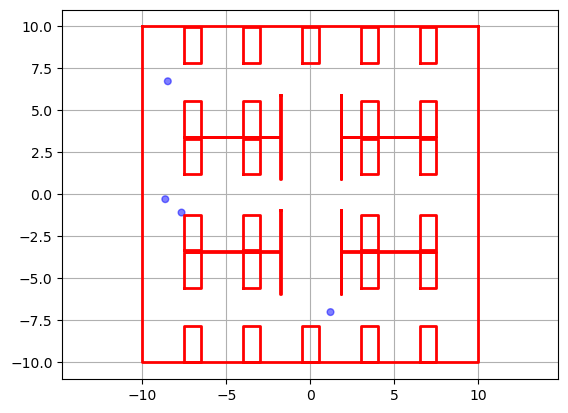

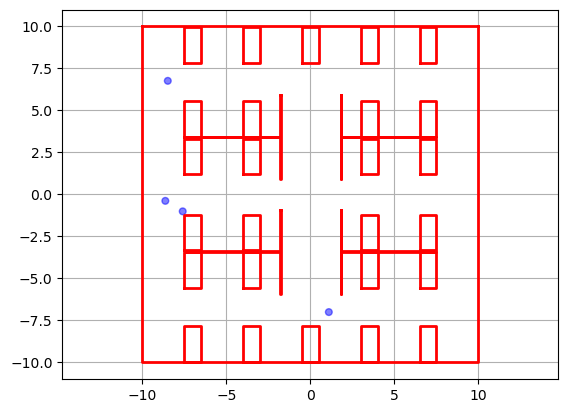

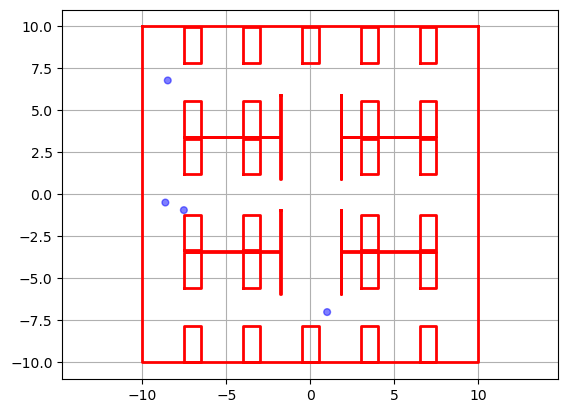

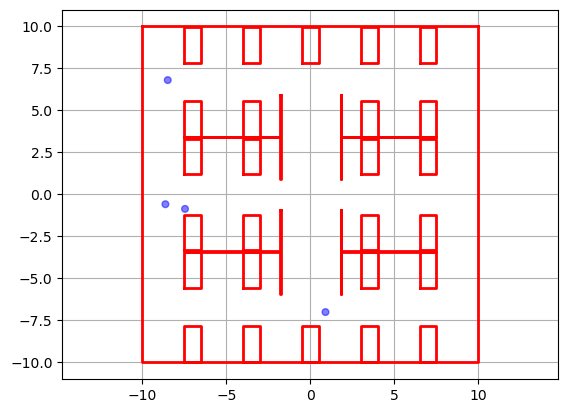

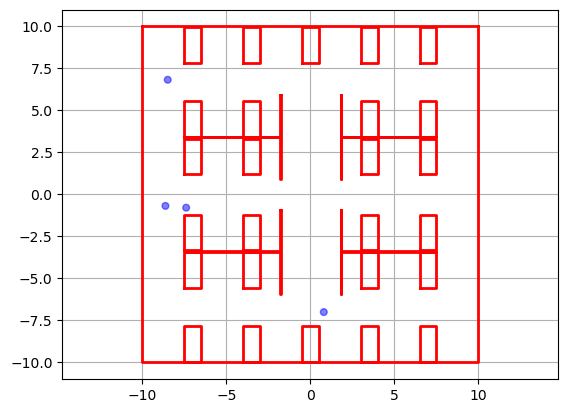

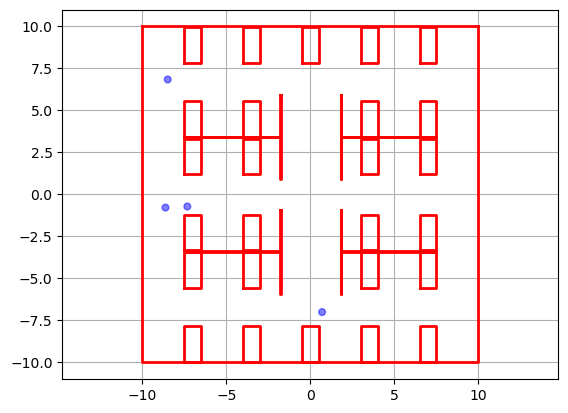

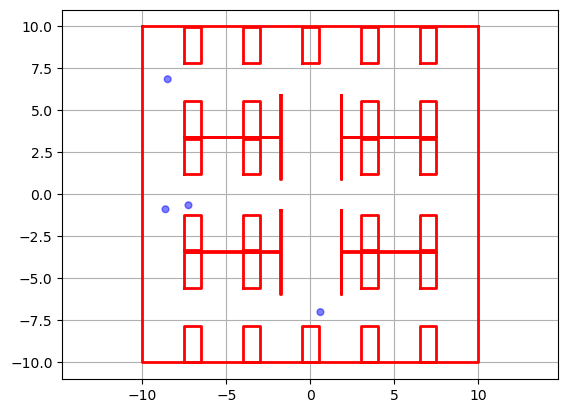

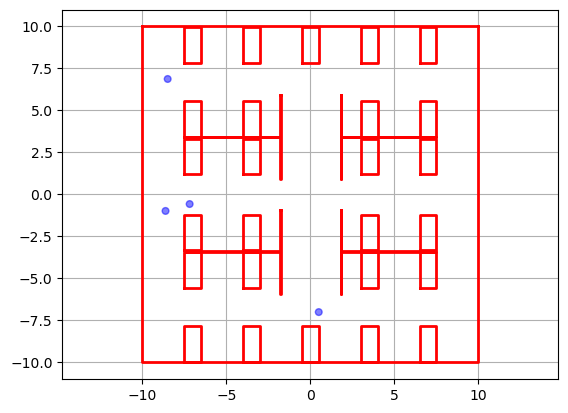

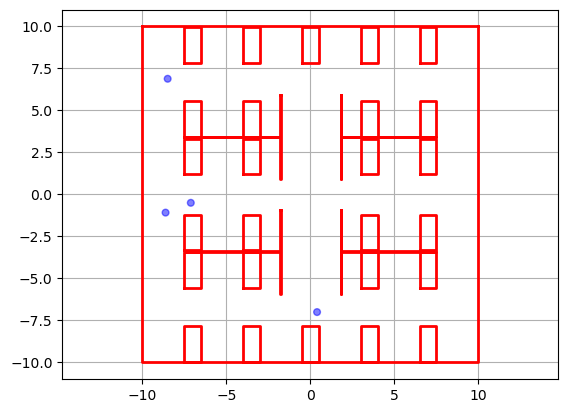

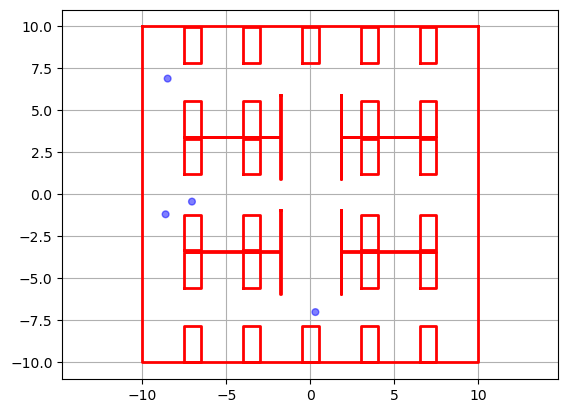

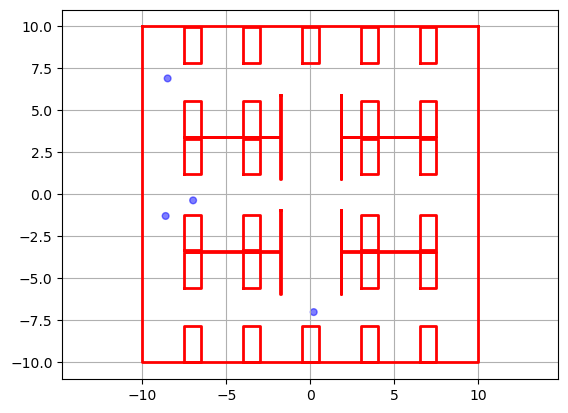

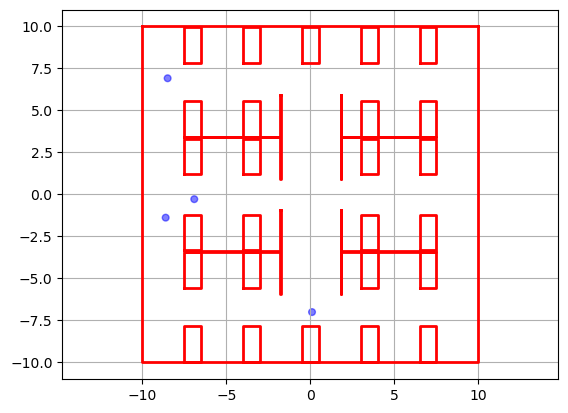

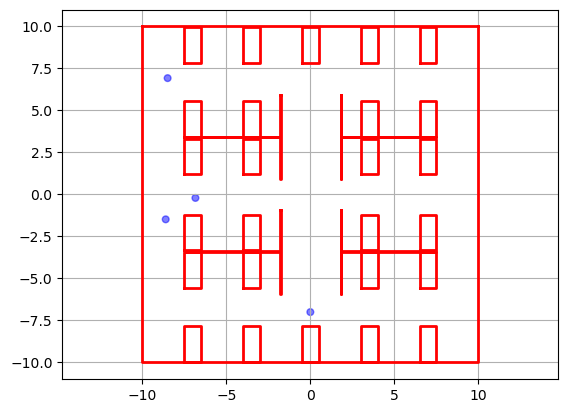

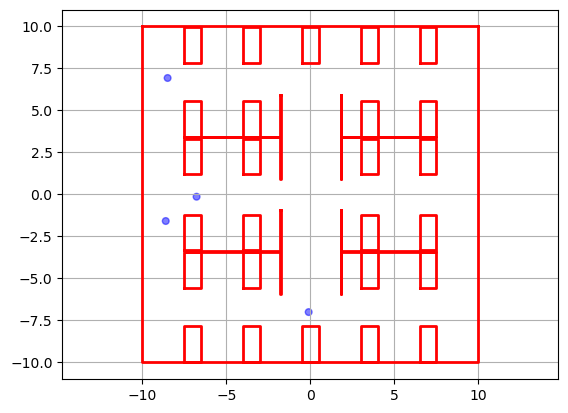

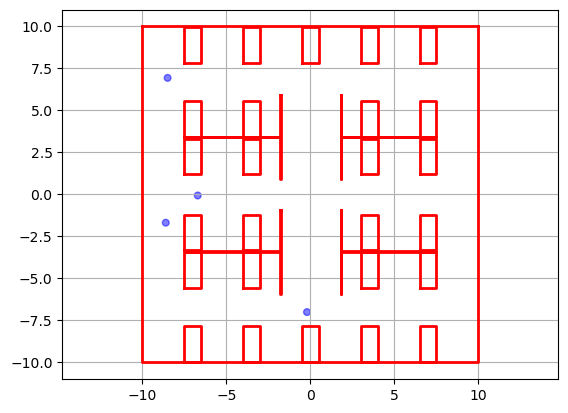

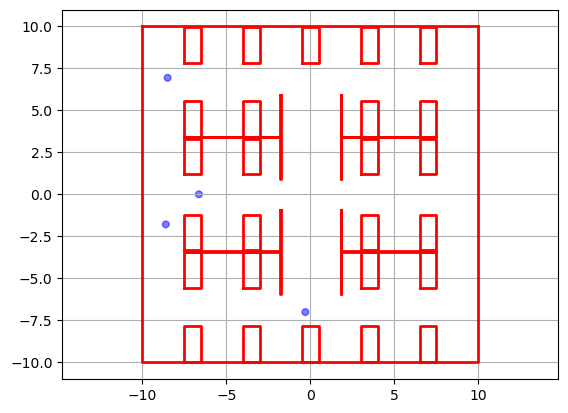

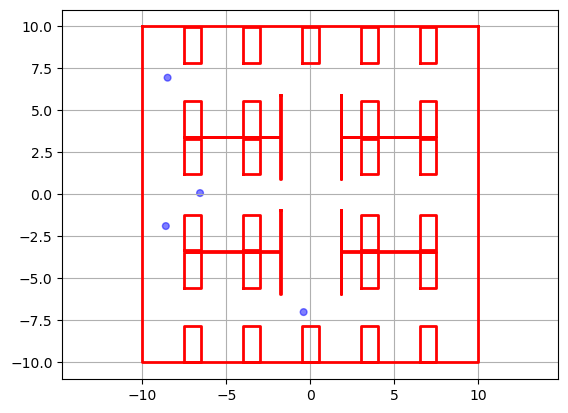

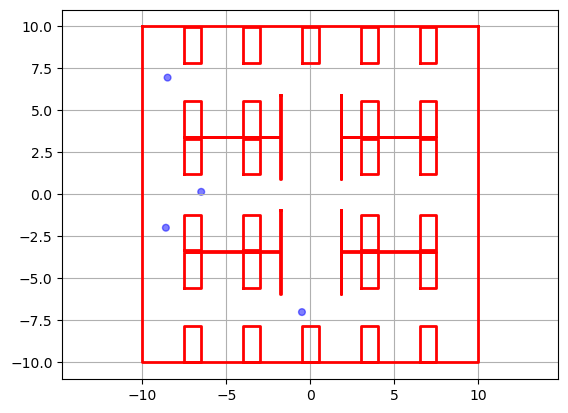

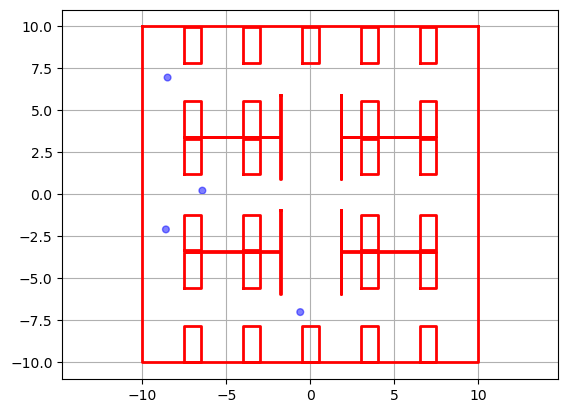

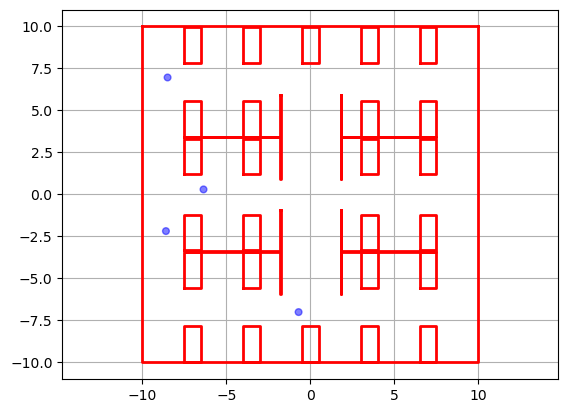

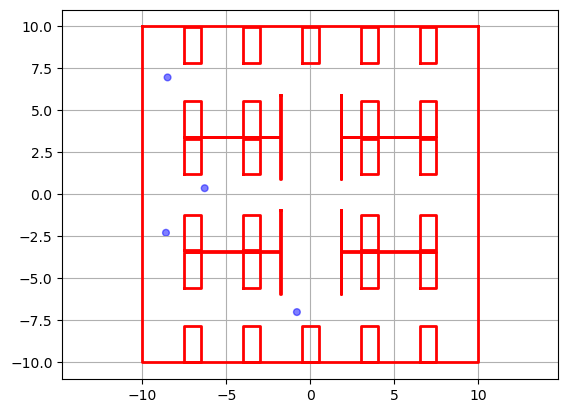

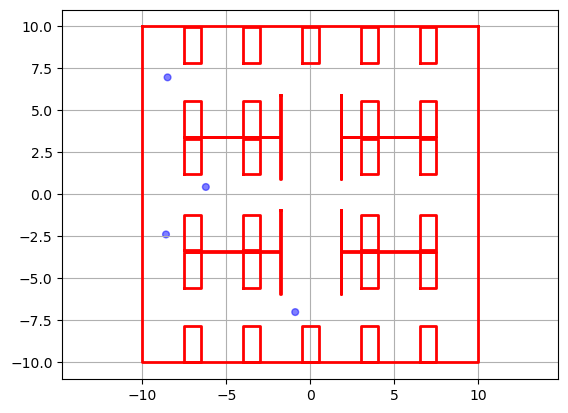

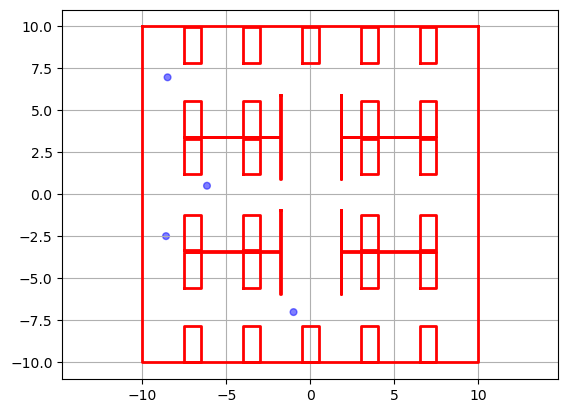

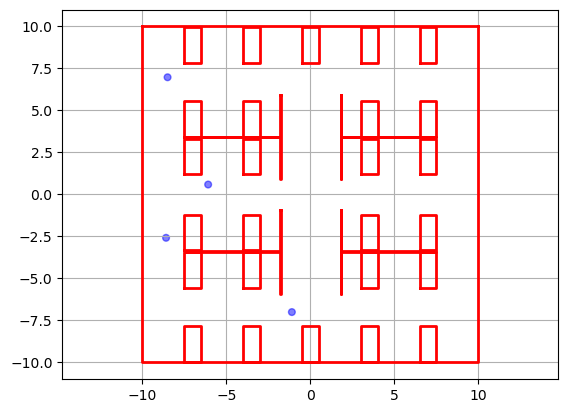

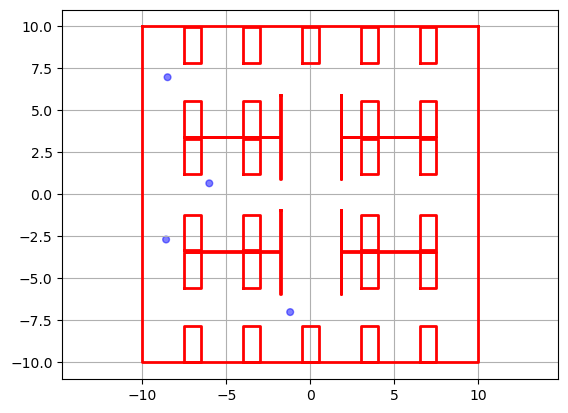

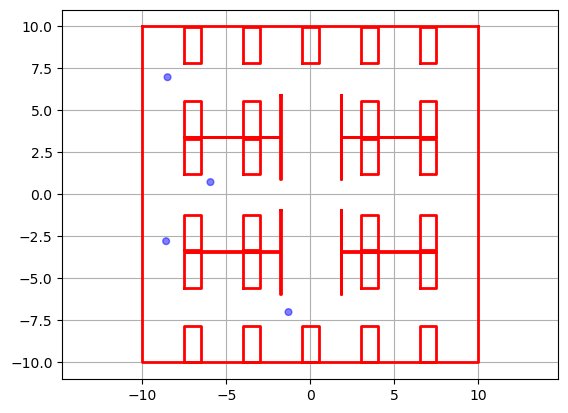

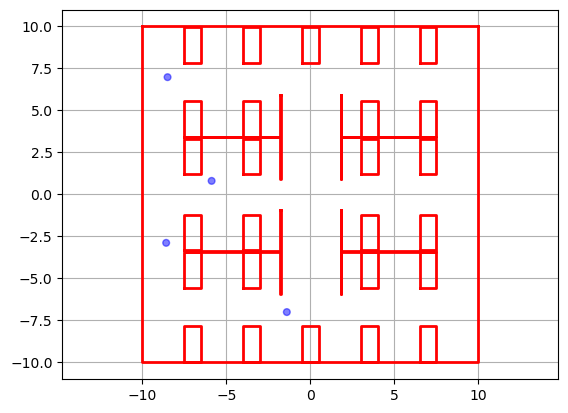

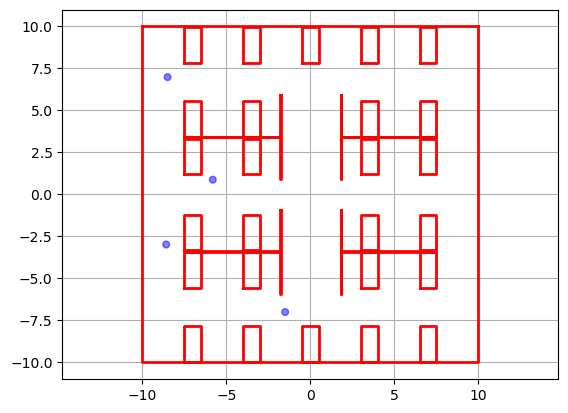

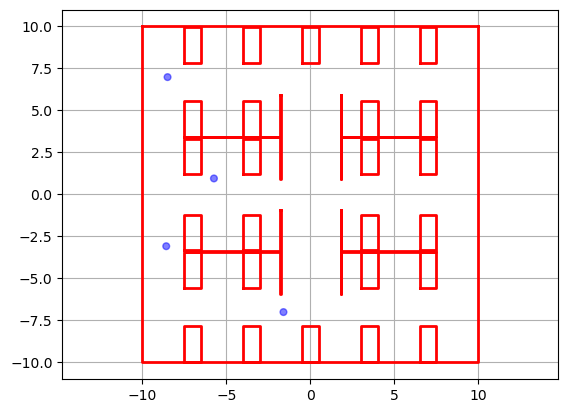

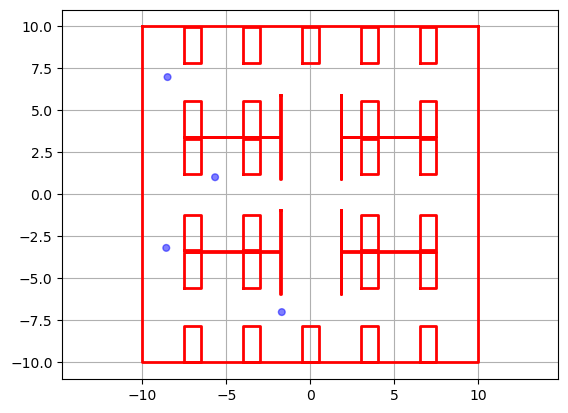

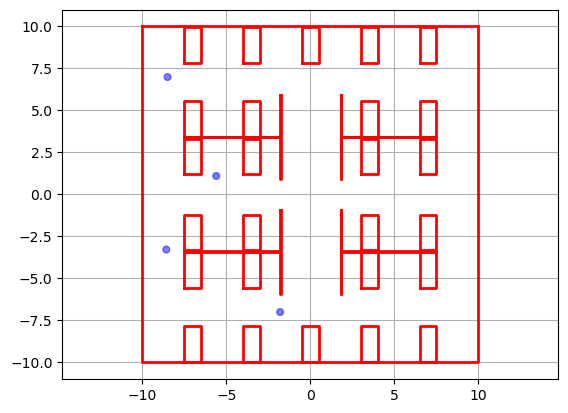

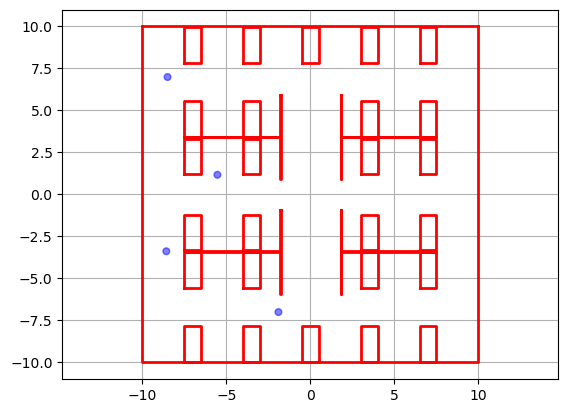

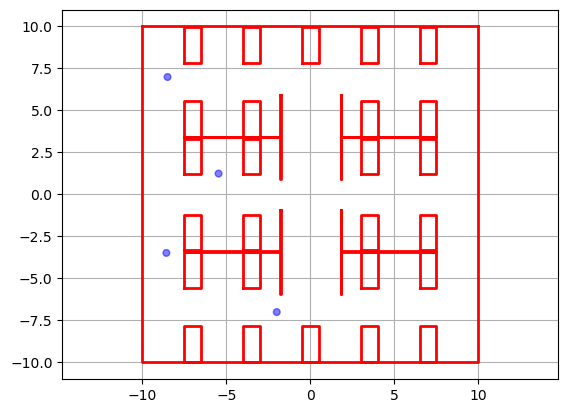

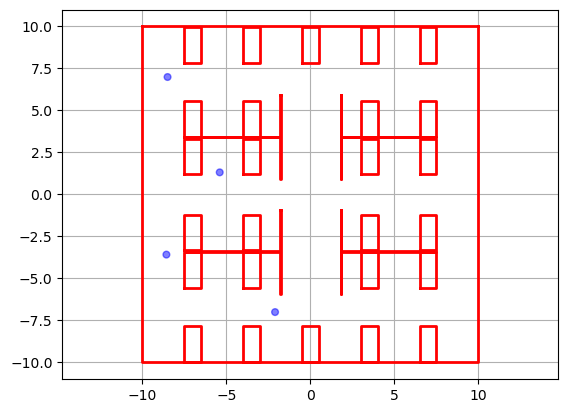

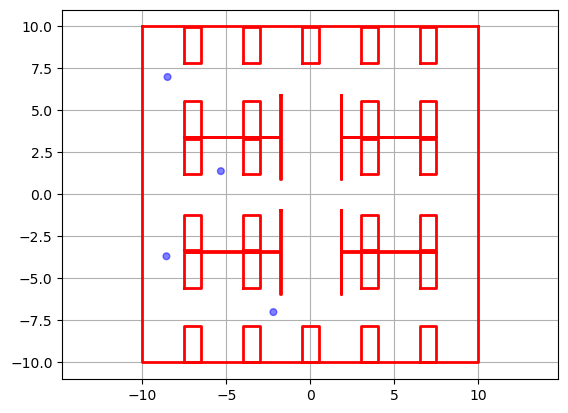

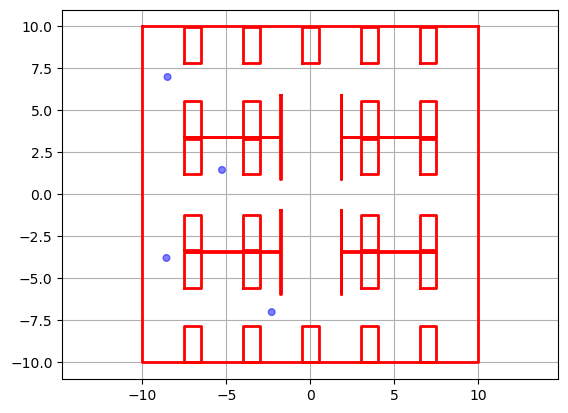

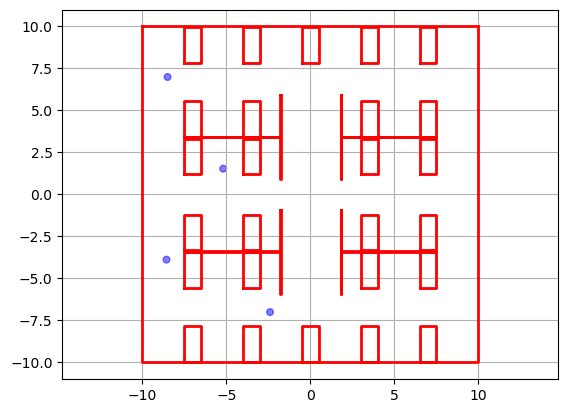

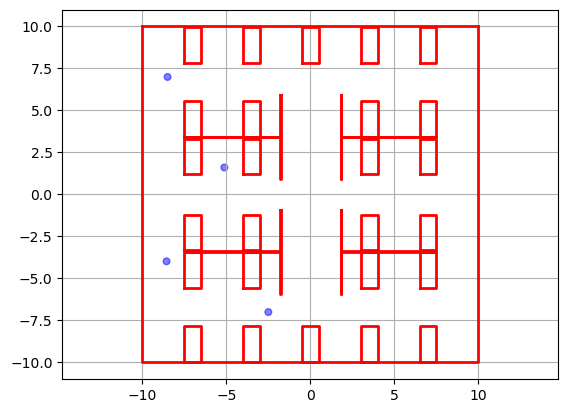

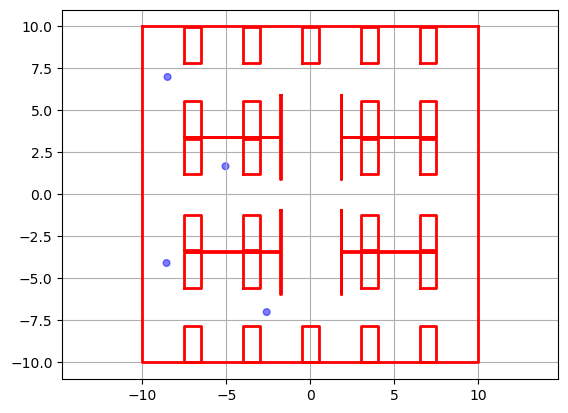

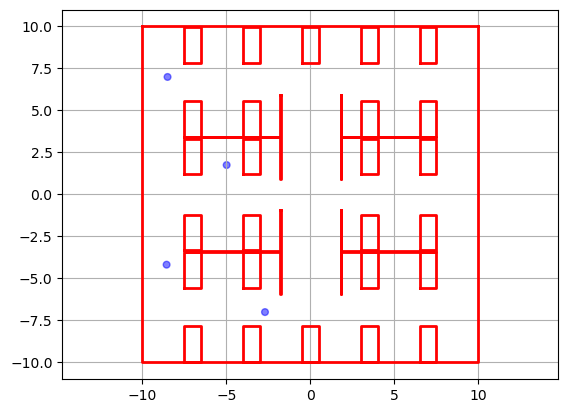

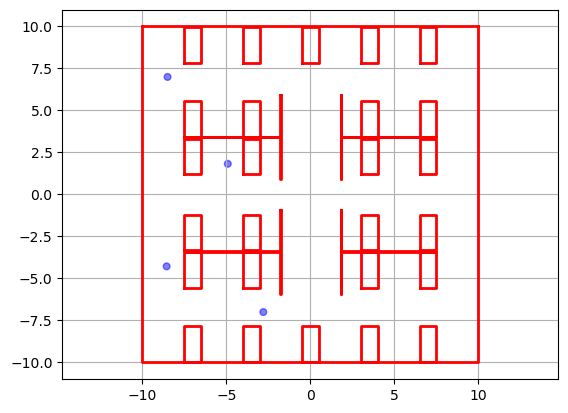

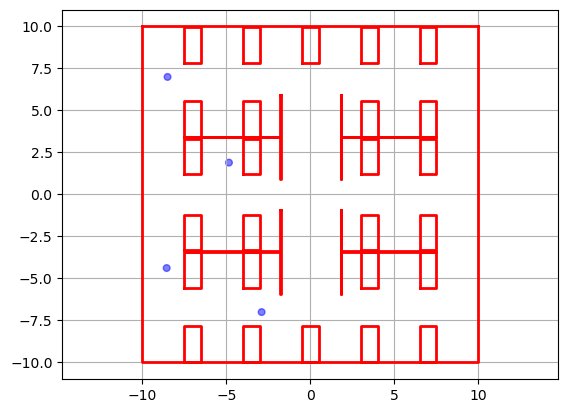

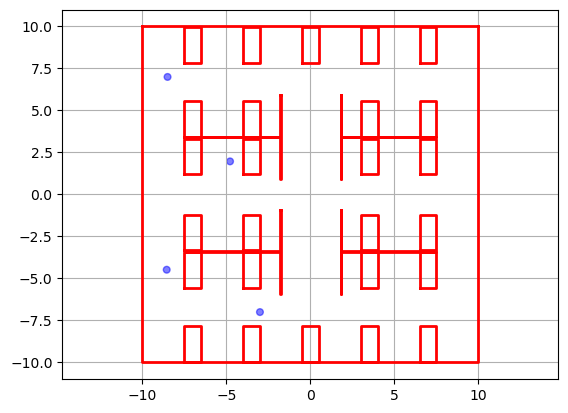

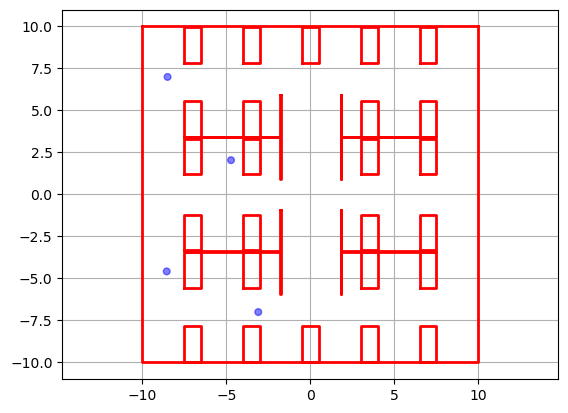

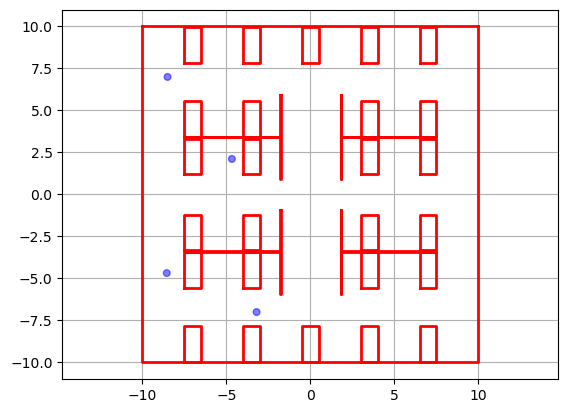

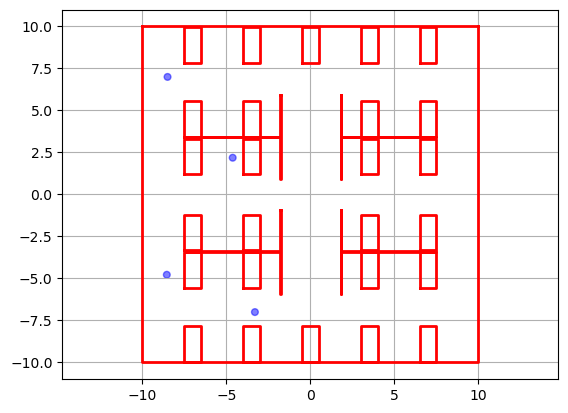

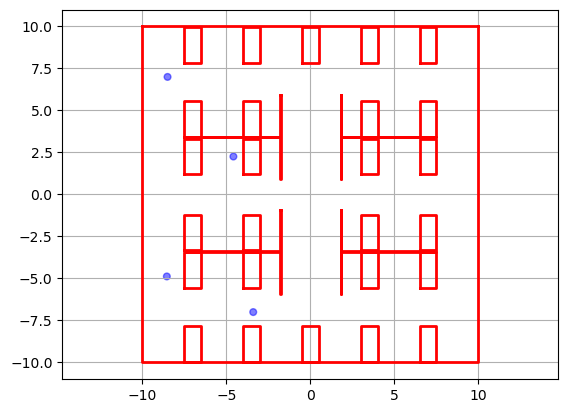

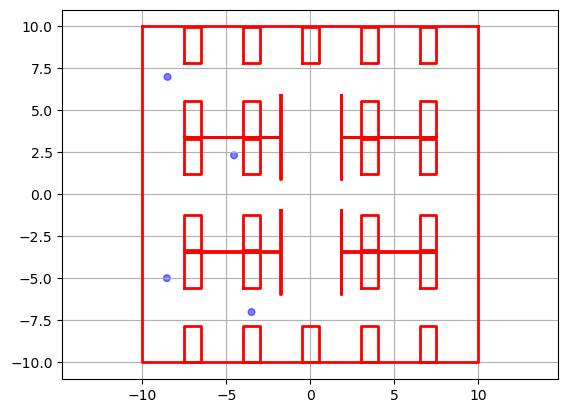

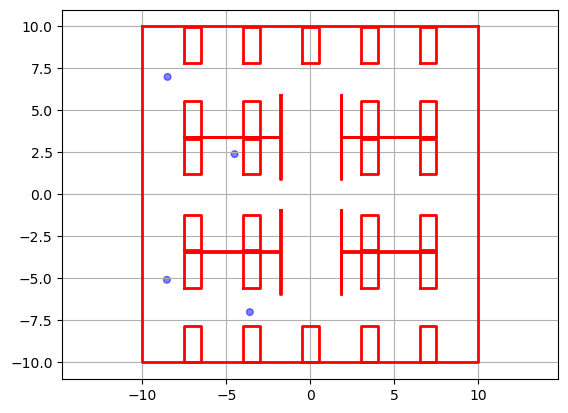

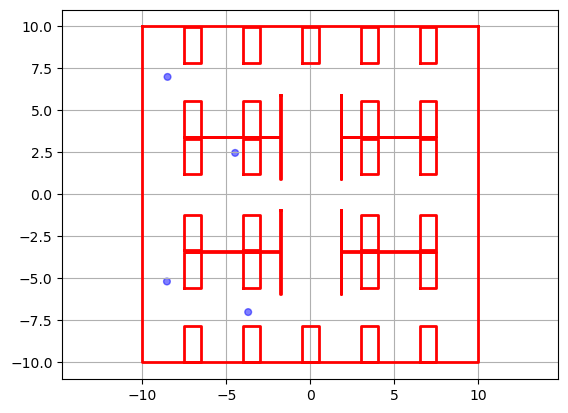

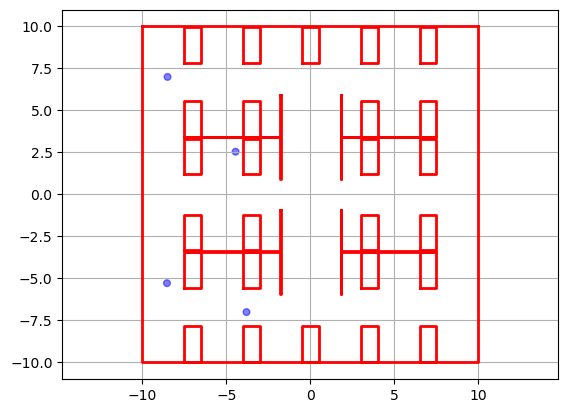

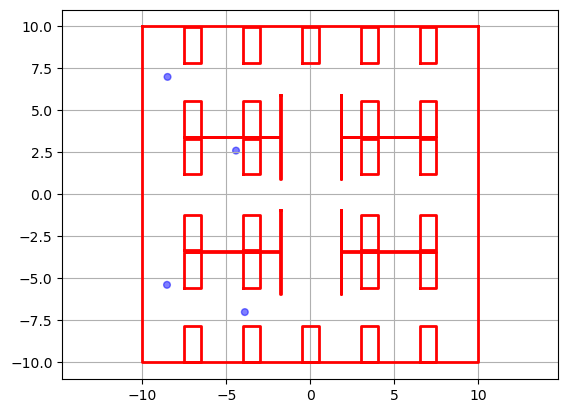

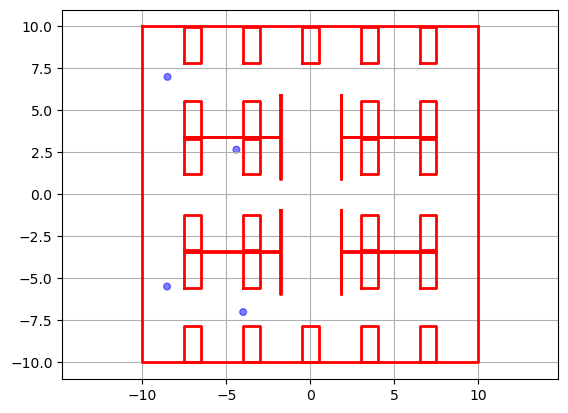

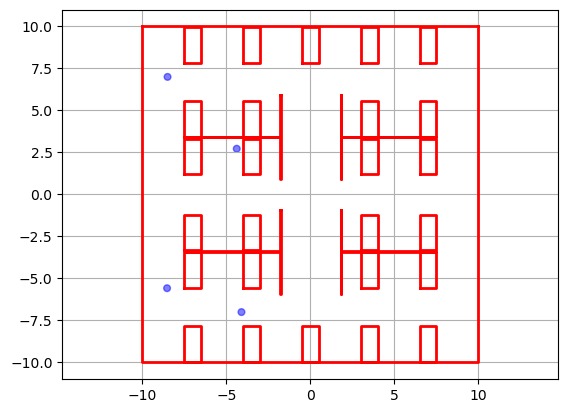

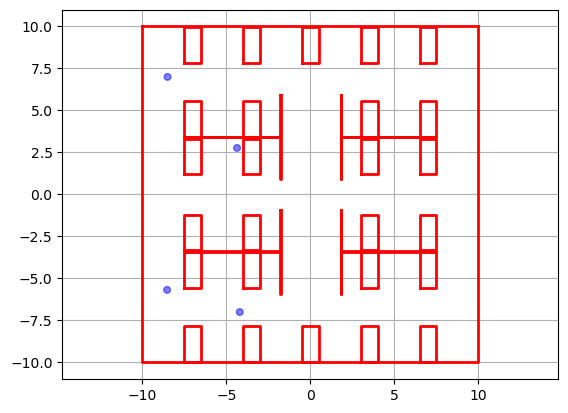

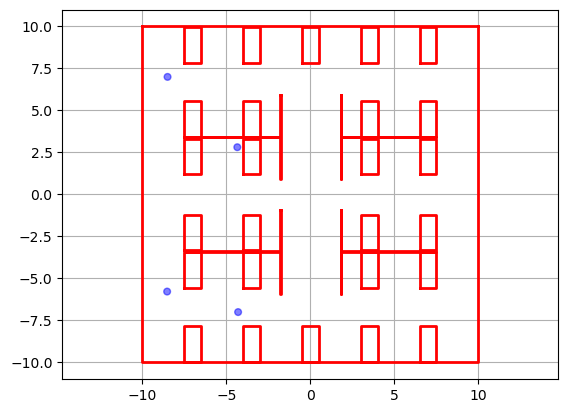

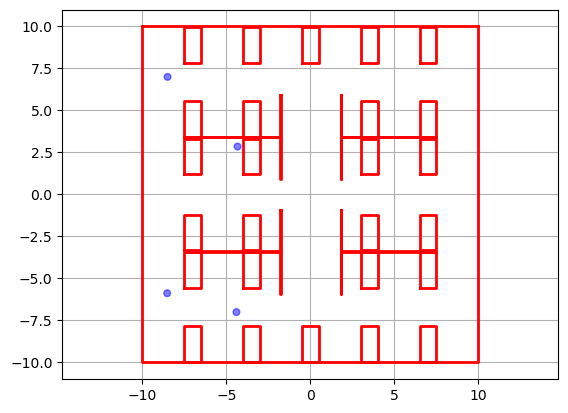

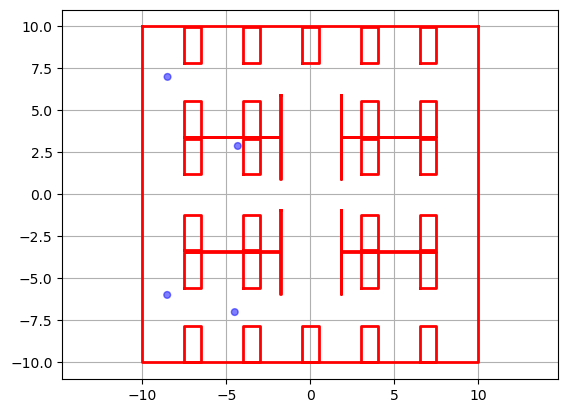

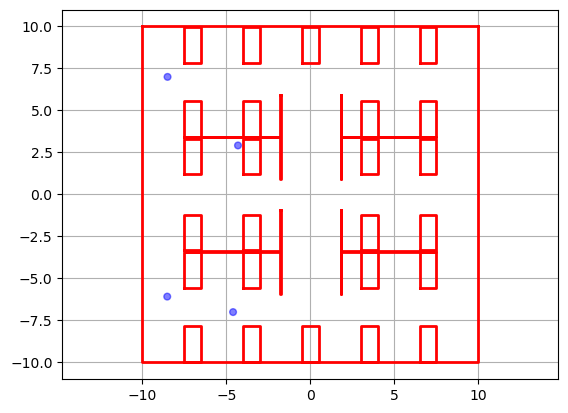

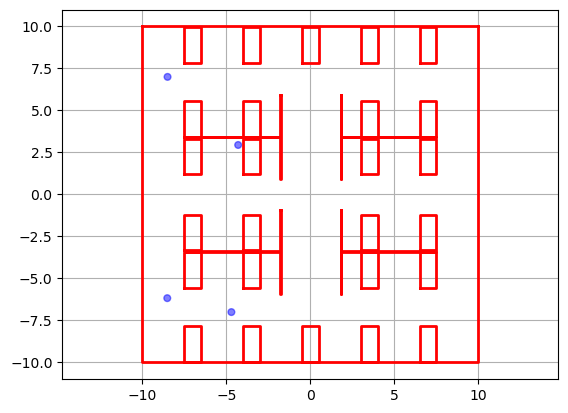

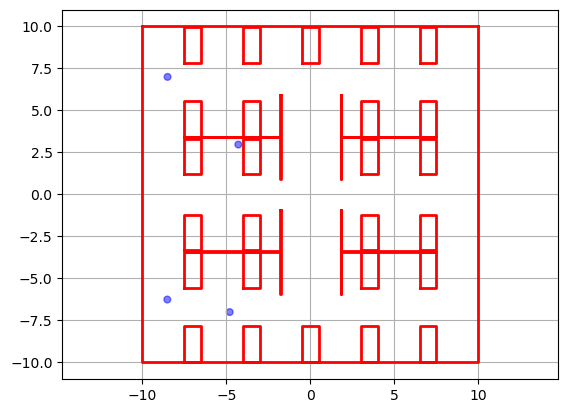

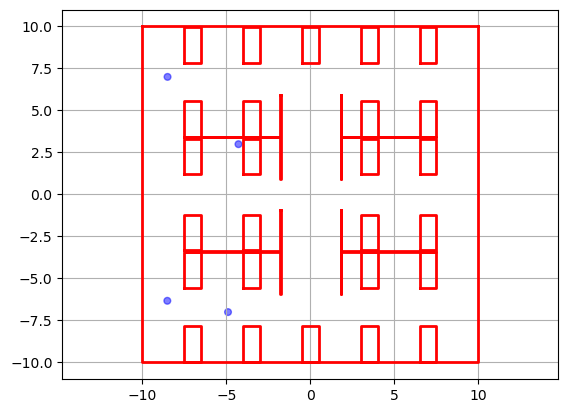

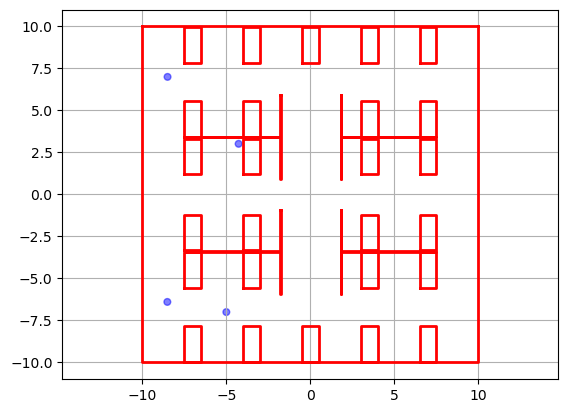

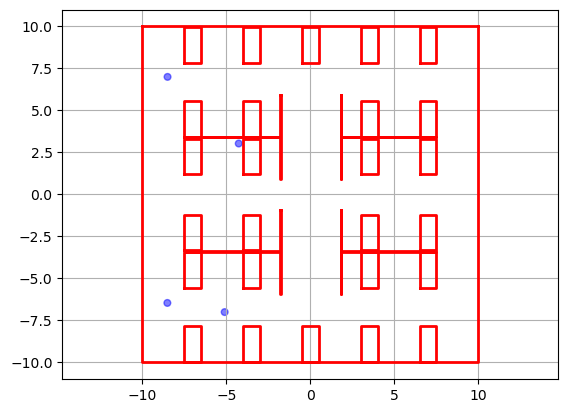

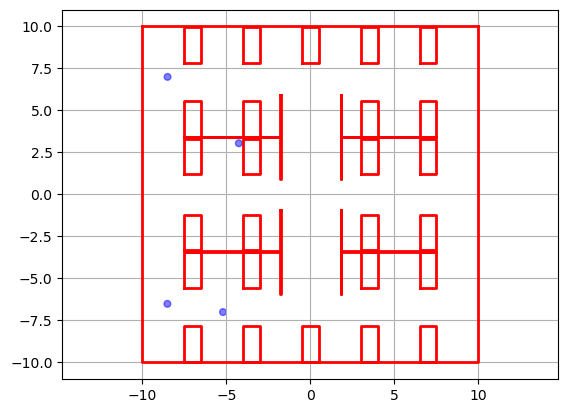

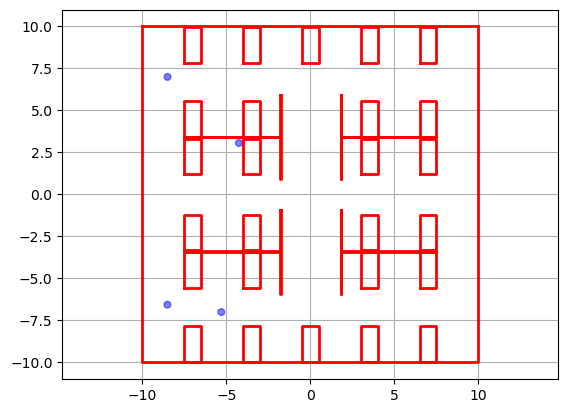

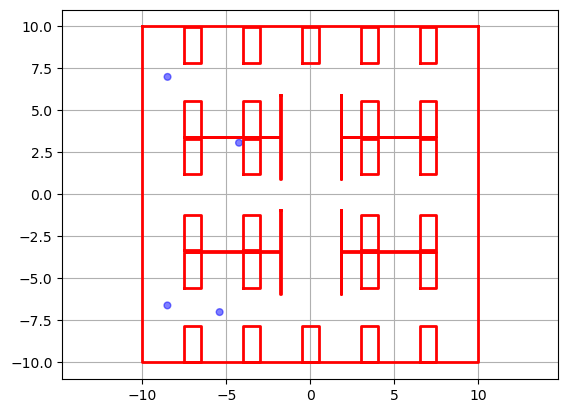

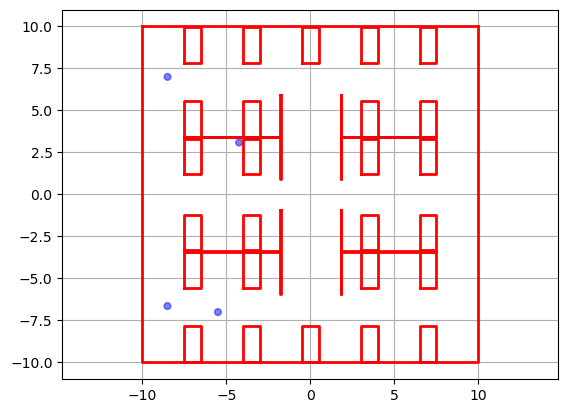

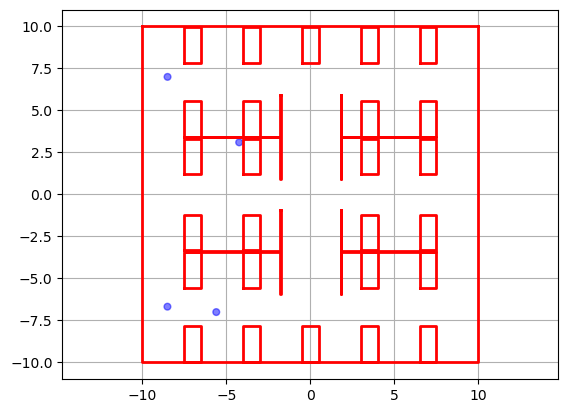

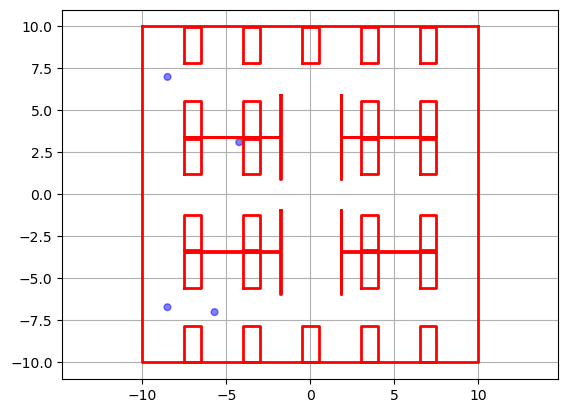

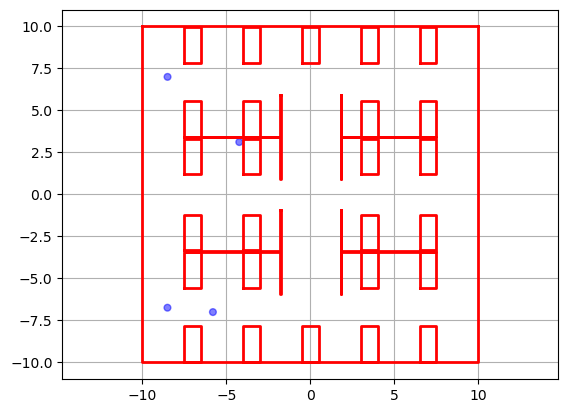

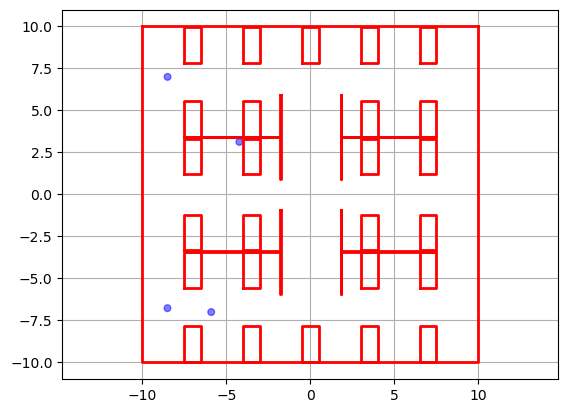

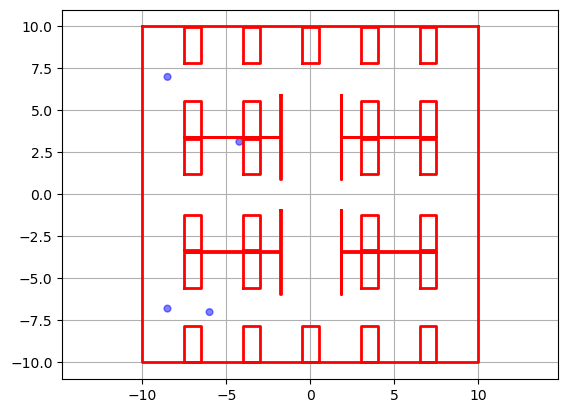

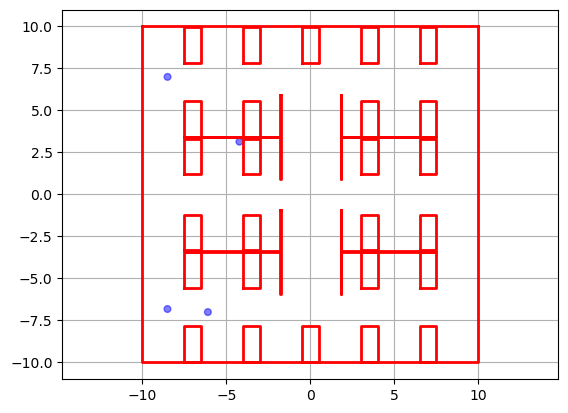

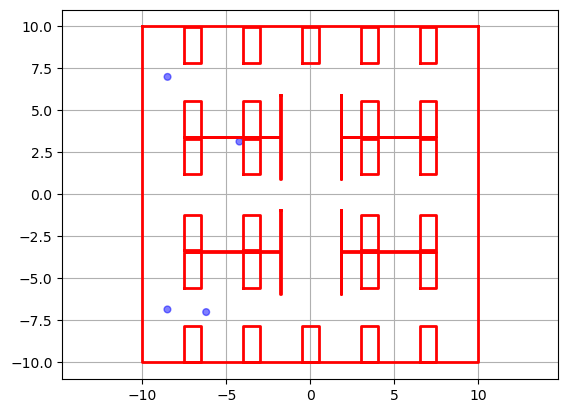

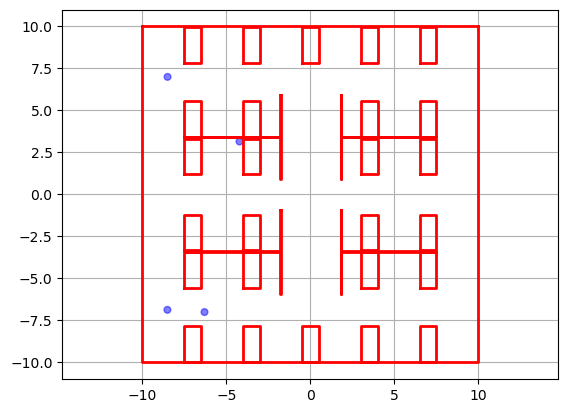

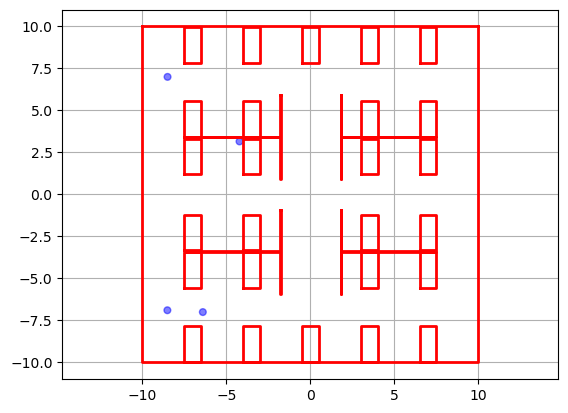

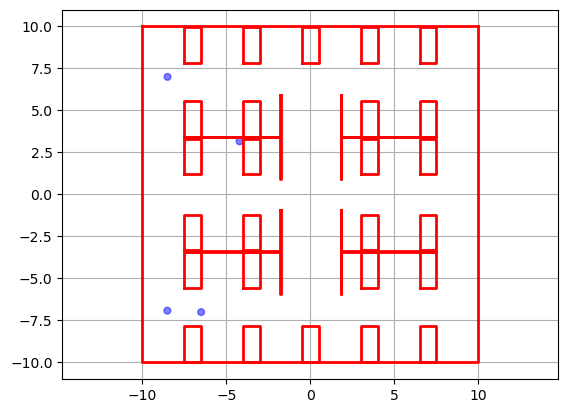

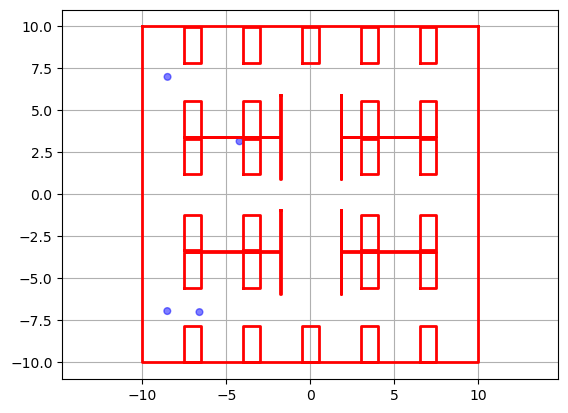

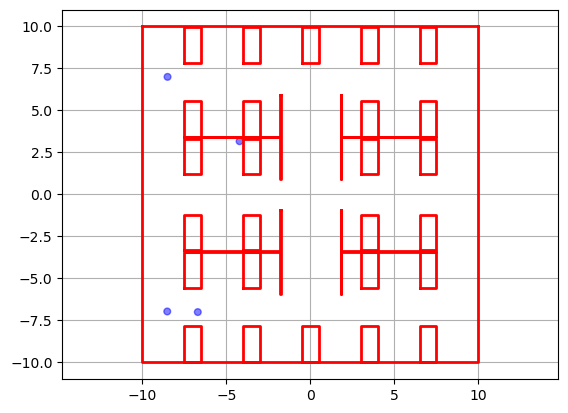

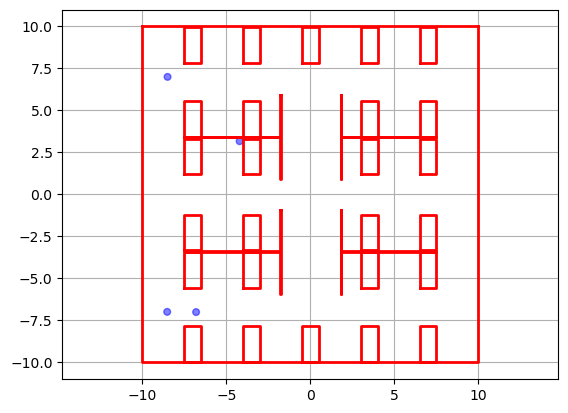

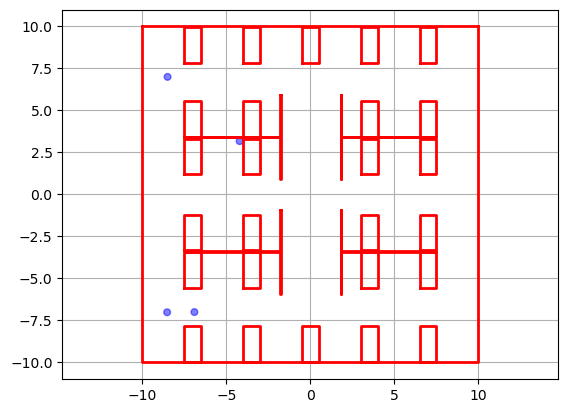

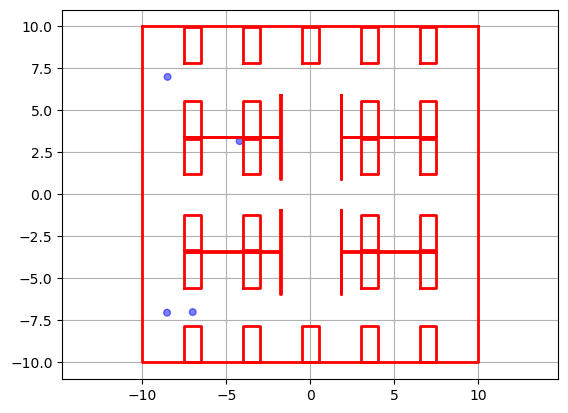

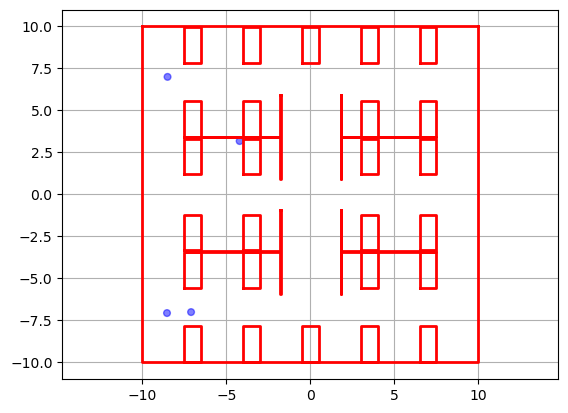

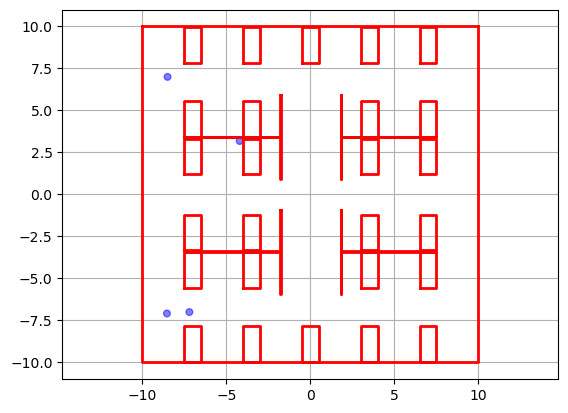

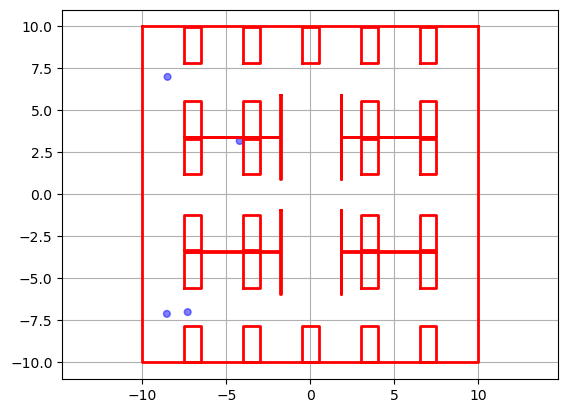

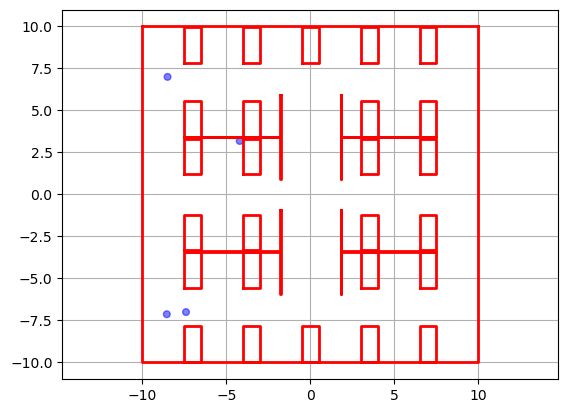

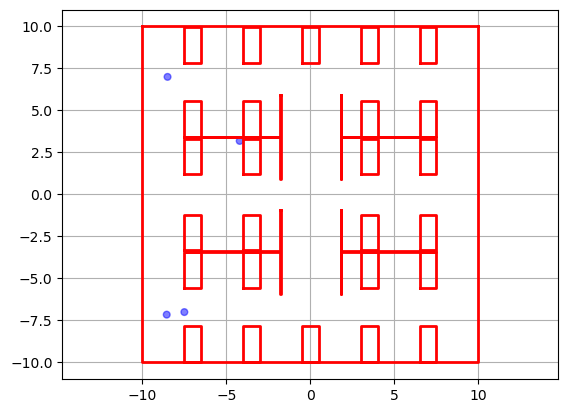

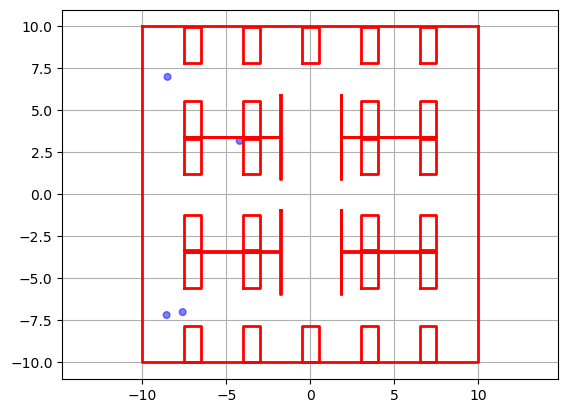

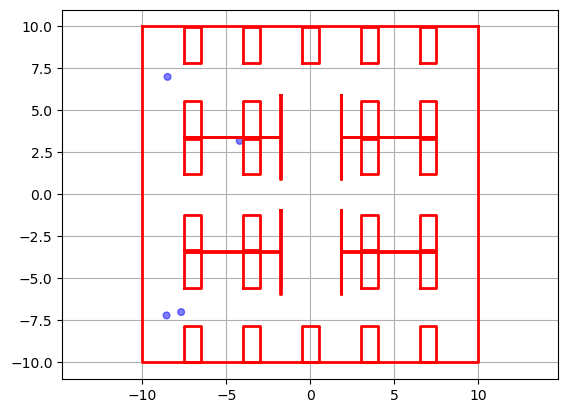

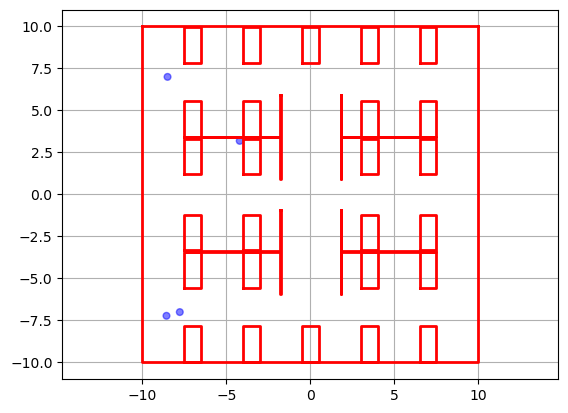

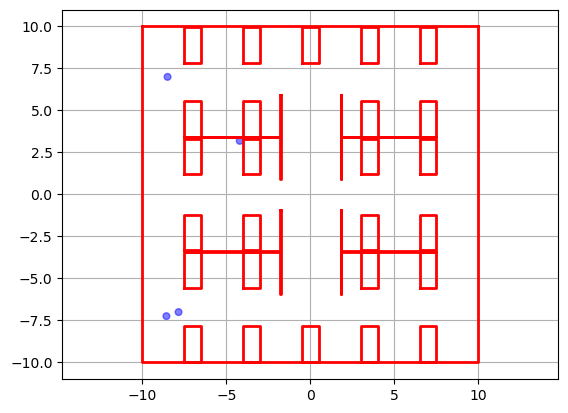

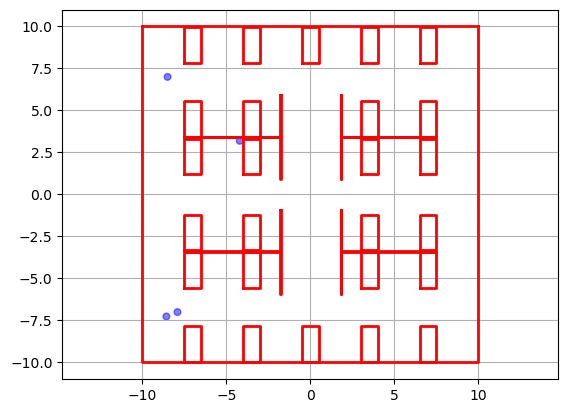

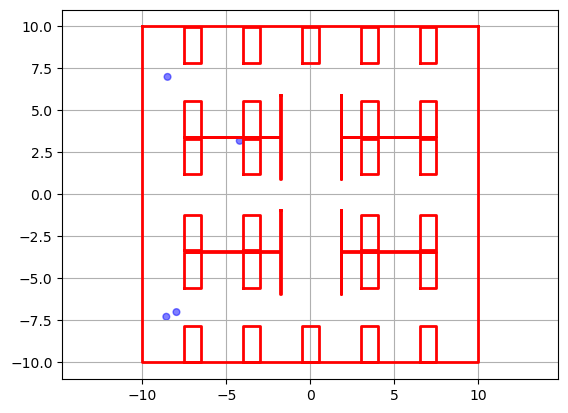

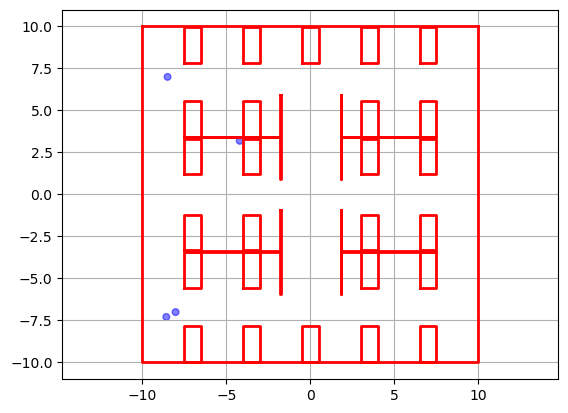

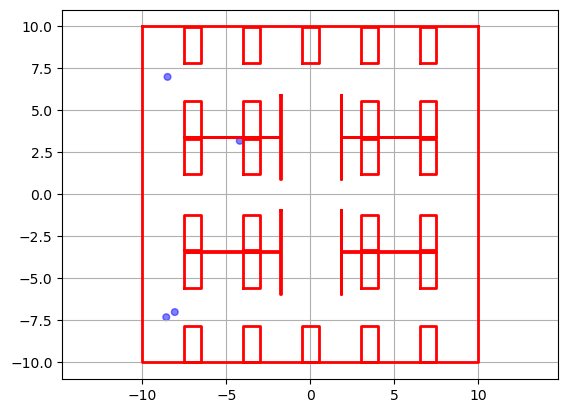

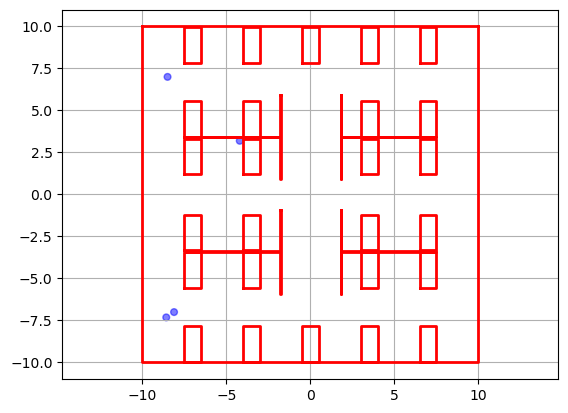

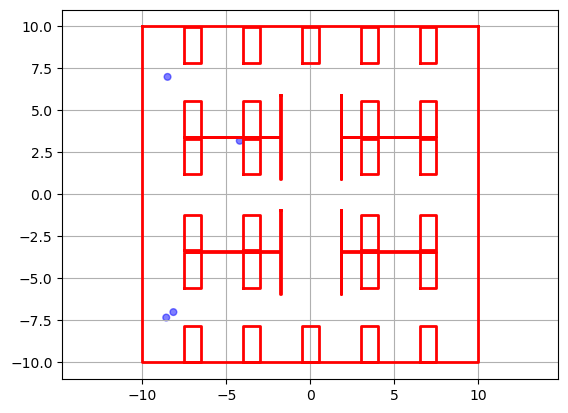

KeyboardInterrupt: 

In [29]:
import pyrvo2
import numpy as np
import math, time
from pyrvo2 import *
import matplotlib.pyplot as plt
from SimEnv import get_edges, SimulationEnvironment_Scenario2, SimulationEnvironment_Scenario6, \
    SimulationEnvironment_CubeCollection, SimulationEnvironment_Warehouse, SimulationEnvironment_CA
from shapely.geometry import Polygon, Point, LineString
from offpolicy.envs.lasercar.env_core import EnvCore
def setupScenario(sim):
    goals=[]
    sim.setTimeStep(0.1)
    sim.setAgentDefaults(neighborDist=5, maxNeighbors=32, timeHorizon=5.0, timeHorizonObst=1.0, radius=0.2, maxSpeed=1.0, velocity=np.array([0,0]))
    for car in env.cars:
        sim.addAgent(np.array([car['x'],car['y']]))
        goals.append(np.array([car['goal_x'],car['goal_y']]))
    for obstale_list in obstale_lists:
        sim.addObstacle(obstale_list)
    sim.processObstacle()
    return goals

def setPreferredVelocities(sim, goals):
    for i in range(sim.getNumAgents()):
        goalVector = goals[i] - sim.getAgentPosition(i)
        if (np.linalg.norm(goalVector) > 1.0):
            goalVector = goalVector/np.linalg.norm(goalVector)
        sim.setAgentPrefVelocity(i, goalVector)

def reachedGoal(sim, goals):
    for i in range(sim.getNumAgents()):
        if (np.linalg.norm(sim.getAgentPosition(i) - goals[i]) > sim.getAgentRadius(i)):
            return False
    return True

def visualize(sim):
    plt.clf()  # Clear the previous frame
    
    # Plot agents
    for i in range(sim.getNumAgents()):
        pos = sim.getAgentPosition(i)
        radius = sim.getAgentRadius(i)
        circle = plt.Circle((pos[0], pos[1]), radius, color='blue', alpha=0.5)
        plt.gca().add_artist(circle)
    
    # Plot obstacles
    for obstale_list in obstale_lists:
        x = [point[0] for point in obstale_list]
        y = [point[1] for point in obstale_list]
        plt.plot(x, y, 'r-', linewidth=2)
        # Close the obstacle shape
        plt.plot([x[-1], x[0]], [y[-1], y[0]], 'r-', linewidth=2)
    
    # Set plot limits (equivalent to your world_size)
    plt.xlim(-10, 10)  # Adjust based on your world_size
    plt.ylim(-10, 10)  # Adjust based on your world_size
    plt.axis('equal')  # Equal aspect ratio
    plt.grid(True)
    # plt.title(f"Simulation Time: {sim.getGlobalTime():.1f}")
    
    plt.pause(0.1)  # Pause to show the animation
class Args:
    num_sensors: int = 16
    Car_resettype: str = "random_target"  # Options: "random_target", "diag"
    num_agents: int = 4
    turnoff_sensor: bool = False
    add_sensor_noise: bool = True
    fixed_theta: bool = True
    scenario: str = "Warehouse"  # Use an available scenario
    share_reward: bool = False
    sensor_gussian_noise: float = 0.1
    save_history: bool = True
    plot_traj: bool = True
    traj_hold: bool = True
    plot_sensor_line: bool = True
    ifi: float = 0.1  # Animation interval

# Set up the parameters
args = Args()

# Create the environment
env = EnvCore(args)
env.seed(42)  # For reproducibility

# Reset the environment
observations = env.reset()
world_size=env.SimEnv.area_size
obstale_lists = []
obstale_list = []
width=0.05
for line in env.SimEnv.inner_lines:
    rectangle = line_to_rectangle(line, width)
    obstale_lists.append(rectangle)

for line in env.SimEnv.border:# for boundary, clockwise
    #reverse order
    obstale_lists.append([line[i] for i in range(len(line)-2,-1,-1)])
print(obstale_lists)
    
# print(obstale_lists)
for obstacle in env.SimEnv.obstacles:
    edge = get_edges(list(obstacle.exterior.coords))
    obstale_list = [(seg[0], seg[1]) for seg in edge]
    obstale_list.append((edge[-1][2], edge[-1][3]))
    # print(obstale_list)
    obstale_lists.append(obstale_list)
# print(f"obstacle num {len(obstale_lists)}")

# rectangle = line_to_rectangle(line_segment, width)
# Initialize the plot
plt.ion()  # Turn on interactive mode
fig = plt.figure(figsize=(10, 10))

start_time = time.time()
sim = RVOSimulator()
goals = setupScenario(sim)

while not reachedGoal(sim, goals):
    setPreferredVelocities(sim, goals)
    sim.step()
    visualize(sim)

plt.ioff()  # Turn off interactive mode
plt.show()  # Keep the final frame visible


In [23]:
A=list(Point(0,0).buffer(0.5,quad_segs=4).exterior.coords)#it's clockwise
print(A)
print(A.reverse())
print(A)

[(0.5, 0.0), (0.46193976625564337, -0.1913417161825449), (0.3535533905932738, -0.35355339059327373), (0.19134171618254492, -0.46193976625564337), (3.061616997868383e-17, -0.5), (-0.19134171618254486, -0.46193976625564337), (-0.35355339059327373, -0.3535533905932738), (-0.46193976625564337, -0.19134171618254495), (-0.5, -6.123233995736766e-17), (-0.4619397662556434, 0.19134171618254484), (-0.35355339059327384, 0.35355339059327373), (-0.19134171618254517, 0.46193976625564326), (-9.184850993605148e-17, 0.5), (0.191341716182545, 0.4619397662556433), (0.3535533905932737, 0.35355339059327384), (0.46193976625564326, 0.1913417161825452), (0.5, 0.0)]
None
[(0.5, 0.0), (0.46193976625564326, 0.1913417161825452), (0.3535533905932737, 0.35355339059327384), (0.191341716182545, 0.4619397662556433), (-9.184850993605148e-17, 0.5), (-0.19134171618254517, 0.46193976625564326), (-0.35355339059327384, 0.35355339059327373), (-0.4619397662556434, 0.19134171618254484), (-0.5, -6.123233995736766e-17), (-0.4619

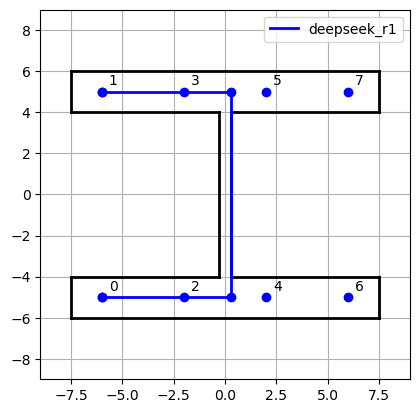

In [ ]:
from SimEnv import get_edges, SimulationEnvironment_Scenario2, SimulationEnvironment_Scenario6, \
    SimulationEnvironment_CubeCollection, SimulationEnvironment_Warehouse, SimulationEnvironment_CA
import matplotlib.pyplot as plt
# path=[(-6.0, -5.0),
#     (-0.3, -5.0),
#     (-0.3, -4.0),
#     (0.0, 4.0),
#     (0.3, 4.0),
#     (0.3, 5.0),
#     (-6.0, 5.0)]

# path=[(-6, -5.0), (-7.5, -5.0), (-7.5, 5.0), (-6, 5.0)]#siliconflow qwq
# path =[(-6,-5), (0.3, -5), (0.3, 3.9), (-0.3, 3.9), (-0.3,5), (-6,5)] #16K qwq
# path = [(-6, -1.6), (-6, 0.6), (7.5, 0.6), (7.5, 1.6)]# ds 1.5b 16k
# path=[(-6,-4),(6,0),(7,1),(8,2),(9,3),(10,4),(11,5)]# ds 1.5b 4k
env=SimulationEnvironment_Scenario2()
env.display_environment(show=0)
# for point in path:
#     plt.plot(point[0],point[1],'ro')
# plt.plot([p[0] for p in path],[p[1] for p in path],'r-',linewidth=2,label='16K_qwq32b')
# path = [
#     (-6, -5),
#     (0.3, -5),
#     (0.3, 4),
#     (0.3, 5),
#     (-6, 5)
# ]
path=[(-6, -5), (0.3, -5), (0.3, 5), (-6, 5)]##16K qwq A6000
for point in path:
    plt.plot(point[0],point[1],'bo')
plt.plot([p[0] for p in path],[p[1] for p in path],'b-',linewidth=2,label='deepseek_r1')
plt.legend()
plt.show()
# plt.savefig("path.png",dpi=300, bbox_inches='tight')

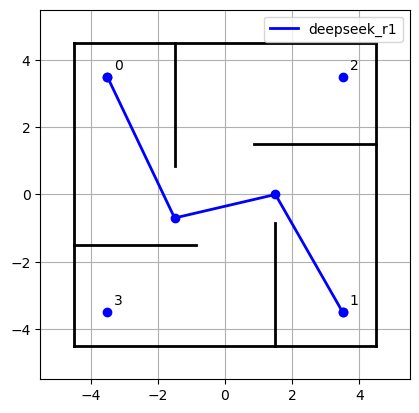

In [10]:
from SimEnv import get_edges, SimulationEnvironment_Scenario2, SimulationEnvironment_Scenario6, \
    SimulationEnvironment_CubeCollection, SimulationEnvironment_Warehouse, SimulationEnvironment_CA
import matplotlib.pyplot as plt
env=SimulationEnvironment_CA()
env.display_environment(show=0)

# path=[(-3.5, 3.5), (-1.5, -0.8), (3.5, -3.5)]##16K qwq A6000
# path=[(-3.5, 3.5), (-1.5, 0.8), (1.5, -4.5), (3.5, -3.5)]
path=[(-3.5, 3.5), (-1.5, -0.7), (1.5, 0), (3.5, -3.5)]
for point in path:
    plt.plot(point[0],point[1],'bo')
plt.plot([p[0] for p in path],[p[1] for p in path],'b-',linewidth=2,label='deepseek_r1')
plt.legend()
plt.show()
# plt.savefig("path.png",dpi=300, bbox_inches='tight')

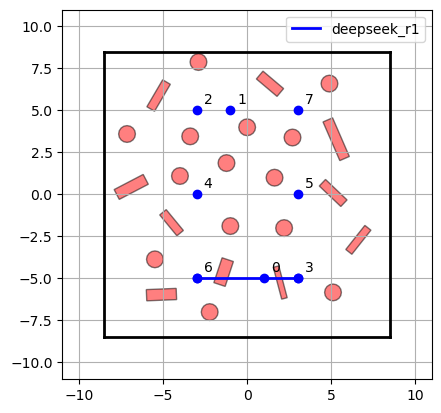

[[(-8.5, 8.5), (-8.5, -8.5), (8.5, -8.5), (8.5, 8.5), (-8.5, 8.5)]]
[[(-5.968789881006918, 5.221555759840556), (-5.511502133634095, 4.953623089001988), (-4.57121011899308, 6.558444240159443), (-5.028497866365903, 6.826376910998012), (-5.968789881006918, 5.221555759840556)], [(-7.917081412657099, 0.2916636490649136), (-7.6118410705194, -0.293510114471748), (-5.882918587342901, 0.6083363509350885), (-6.188158929480599, 1.1935101144717501), (-7.917081412657099, 0.2916636490649136)], [(-4.181179219068674, -2.460306548509199), (-3.7952381358435416, -2.142423739475726), (-4.818820780931327, -0.8996934514908013), (-5.204761864156459, -1.2175762605242744), (-4.181179219068674, -2.460306548509199)], [(-6.002922450057546, -5.661577398339072), (-5.975596492525679, -6.33101992167096), (-4.197077549942453, -6.258422601660929), (-4.224403507474319, -5.58898007832904), (-6.002922450057546, -5.661577398339072)], [(-1.9823404906998385, -5.248732497085582), (-1.3083833438613055, -5.4720747551230255), (-

In [ ]:
from SimEnv import get_edges, SimulationEnvironment_Scenario2, SimulationEnvironment_Scenario6, \
    SimulationEnvironment_CubeCollection, SimulationEnvironment_Warehouse, SimulationEnvironment_CA
import matplotlib.pyplot as plt
env=SimulationEnvironment_CubeCollection()
env.display_environment(show=0)

# path=[(1, -5), (-1, 5)]##16K qwq A6000
path=[(3, -5),(-3, -5)]

for point in path:
    plt.plot(point[0],point[1],'bo')
plt.plot([p[0] for p in path],[p[1] for p in path],'b-',linewidth=2,label='deepseek_r1')
plt.legend()
plt.show()
print(env.border)
lines=[]
for obs in env.rectangle_obs:
    x,y=obs.exterior.xy
    lines.append([(x0,y0) for x0,y0 in zip(x,y)])
print(lines)

connetcced: True
40 [9.162584620553506, 8.568048256077567, 6.301024782665788, 7.580063740766046, 9.493869047413217, 7.532338881226584, 12.964374935100027, 1.760135770651334] 5.820935487747192


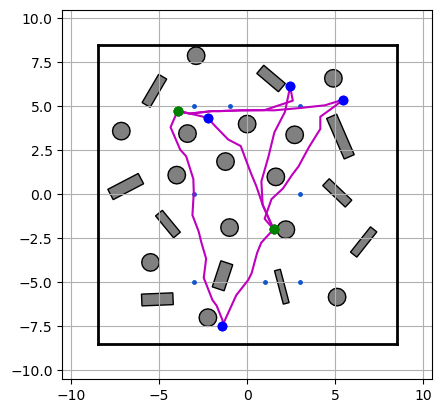

In [1]:
from SimEnv import get_edges, SimulationEnvironment_Scenario2, SimulationEnvironment_Scenario6, \
    SimulationEnvironment_CubeCollection, SimulationEnvironment_Warehouse, SimulationEnvironment_CA,SimulationEnvironment_Unmaze,\
        RRTStar
import matplotlib.pyplot as plt
import time
env=SimulationEnvironment_CubeCollection()

path_rrt, path_astar, rrt_star_path, prm_path=None,None,None,None

# Run PRM to find a path
start_time = time.time()

env.build_roadmap()
num_agent=2
num_goal=4
position=env.sample_MTSP_from_graph(num_agent=num_agent,num_goal=num_goal)
start=[]
goal=[]
for i in range(num_agent):
    for j in range(num_goal):
        start.append(position[i])
        goal.append(position[num_agent+j])
prm_path= env.find_path(start=start, goal=goal)
# prm_path = prm_planner.find_path()
print(2*env.area_size, [env.pathlength(prm_path1) for prm_path1 in prm_path],time.time()-start_time)

ax=env.display_environment(show=0)
# ['b', 'g', 'r', 'c', 'm', 'y', 'k']
if path_rrt or path_astar or rrt_star_path or prm_path:
    if path_rrt:
        path_x, path_y = zip(*path_rrt)
        ax.plot(path_x, path_y, 'r-', label="RRT Path")
    if path_astar:
        path_x, path_y = zip(*path_astar)
        ax.plot(path_x, path_y, 'g-', label="Astar Path")     
    if rrt_star_path:
        path_x, path_y = zip(*rrt_star_path)
        ax.plot(path_x, path_y, 'c-', label="RRTstar Path") 
    if prm_path:
        for prm_path1 in prm_path:
            path_x, path_y = zip(*prm_path1)
            ax.plot(path_x, path_y, 'm-', label="PRM Path")

    for start1, goal1 in zip(start,goal):
        ax.plot(*start1, 'go', label="Start")
        ax.plot(*goal1, 'bo', label="Goal")    

else:
    print("No path found.")

plt.show()

In [2]:
for _ in range(1000):
    # position=env.sample_MTSP_from_graph(num_agent=num_agent,num_goal=num_goal)
    position=env.sample_MTSP(num_agent=num_agent,num_goal=num_goal)
    start=[]
    goal=[]
    for i in range(num_agent):
        for j in range(num_goal):
            start.append(position[i])
            goal.append(position[num_agent+j])
    prm_path= env.find_path(start=start, goal=goal)

before add node, graph size 1000
after add node, graph size 1001
before add node, graph size 1001
after add node, graph size 1002
before add node, graph size 1002
after add node, graph size 1003
before add node, graph size 1003
after add node, graph size 1004
before add node, graph size 1004
after add node, graph size 1005
before add node, graph size 1005
after add node, graph size 1006
before add node, graph size 1000
after add node, graph size 1001
before add node, graph size 1001
after add node, graph size 1002
before add node, graph size 1002
after add node, graph size 1003
before add node, graph size 1003
after add node, graph size 1004
before add node, graph size 1004
after add node, graph size 1005
before add node, graph size 1005
after add node, graph size 1006
before add node, graph size 1000
after add node, graph size 1001
before add node, graph size 1001
after add node, graph size 1002
before add node, graph size 1002
after add node, graph size 1003
before add node, graph si

In [6]:
list(env.graph.nodes)

[(4.047023694516554, -7.007753266041002),
 (-1.1537378663621958, -7.385432000913925),
 (6.55812907214688, -7.015616178458133),
 (-4.017875190290868, -3.0863764418051005),
 (2.0197035035968547, -3.3608391363897123),
 (-5.560353608840929, -1.1518983972203287),
 (-1.8214648533514843, 7.441307417094304),
 (-8.184332827513348, -4.359999042294347),
 (-2.8939264426117273, -2.884781958217979),
 (-3.956442936095133, -4.3661365164325865),
 (3.6499189690920666, -5.4161564479214075),
 (-7.02428543592251, -3.079820254576086),
 (3.618280566205561, -5.868845944920674),
 (5.34770082239328, -4.123262640536504),
 (-8.041585762294805, 3.925091932050959),
 (6.563026266366489, 1.9158403903845826),
 (-3.402378064696057, 2.116340250750376),
 (-2.447768493852058, -2.0469423245637586),
 (5.860151623748855, 5.583705849869535),
 (8.049910700220206, -2.492464838749253),
 (-6.513253499073663, -2.7779236250308355),
 (-2.7791007438128146, -7.688220101062275),
 (-2.686105511801671, 1.6484155249943662),
 (-0.136723123

In [4]:
for _ in range(1000):
    position=env.sample_MTSP_from_graph(num_agent=num_agent,num_goal=num_goal)
    # position=env.sample_MTSP(num_agent=num_agent,num_goal=num_goal)
    start=[]
    goal=[]
    for i in range(num_agent):
        for j in range(num_goal):
            prm_path= env.find_path(start=position[i], goal=position[num_agent+j])

In [13]:
import numpy as np
num_agent=2
num_goal=4
position=env.sample_MTSP(num_agent=num_agent,num_goal=num_goal)
cost_matrix=np.zeros((num_agent,num_goal),dtype=np.float32)
for i in range(num_agent):
    for j in range(num_goal):
        prm_path = env.find_path(start=position[i], goal=position[num_agent+j])
        cost_matrix[i][j]=env.pathlength(prm_path)
print(cost_matrix)

node num 1000
node num 1000
node num 1000
node num 1000
node num 1000
node num 1000
node num 1000
node num 1000
[[10.6202545  6.224636  14.196581  13.430843 ]
 [17.214006   9.168787   3.7299259  2.2819226]]


In [20]:
import lap
import copy
# print(lap.lapjv(cost_matrix, extend_cost=True))
total_cost, goal_assignment,agent_assignment = lap.lapjv(cost_matrix, extend_cost=True)
print(goal_assignment)
cost_matrix1=copy.copy(cost_matrix)
cost_matrix1[:,2:4]=np.inf
print(cost_matrix1)
total_cost, goal_assignment,agent_assignment = lap.lapjv(cost_matrix1, extend_cost=True)
print(goal_assignment)
cost_matrix1=cost_matrix[:,0:1]
print(cost_matrix1)
total_cost, goal_assignment,agent_assignment = lap.lapjv(cost_matrix1, extend_cost=True)
print(goal_assignment)


[1 3]
[[10.6202545  6.224636         inf        inf]
 [17.214006   9.168787         inf        inf]]
[0 1]
[[10.6202545]
 [17.214006 ]]
[ 0 -1]


In [25]:
import numpy as np
import networkx as nx
graph = nx.Graph()
graph.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)])
print(graph.nodes(),graph.edges())
graph.remove_node(0)
print(graph.nodes(),graph.edges())


[0, 1, 2, 3] [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]
[1, 2, 3] [(1, 2), (1, 3), (2, 3)]


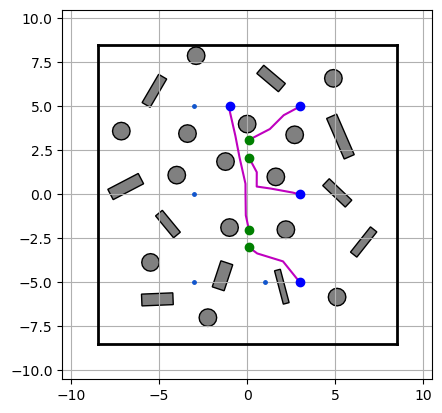

In [3]:
ax=env.display_environment(show=0)
for prm_path1 in prm_path:
    path_x, path_y = zip(*prm_path1)
    ax.plot(path_x, path_y, 'm-', label="PRM Path")
for start1, goal1 in zip(startn,goal[:4]):
    ax.plot(*start1, 'go', label="Start")
    ax.plot(*goal1, 'bo', label="Goal")

In [5]:
import torch
import torch.nn as nn
import timeit
# encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8,batch_first=True,device='cuda')
# transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
# src = torch.rand(10, 1, 128).cuda()
# out = transformer_encoder(src)
# out.shape
# timeit.timeit('transformer_encoder(src)', globals=globals(), number=1000)

A=torch.rand(10, 1, 128)
print(A.shape,A.transpose(-2, -1).shape,A.size())

torch.Size([10, 1, 128]) torch.Size([10, 128, 1]) torch.Size([10, 1, 128])


In [3]:
from SimEnv import get_edges, SimulationEnvironment_Scenario2, SimulationEnvironment_Scenario6, \
    SimulationEnvironment_CubeCollection, SimulationEnvironment_Warehouse, SimulationEnvironment_CA,SimulationEnvironment_Unmaze,\
        RRTStar
import networkx as nx
import numpy as np
env=SimulationEnvironment_Scenario2()
env.build_roadmap()

graph conneted: True


In [ ]:
shortest_paths_weighted = nx.all_pairs_dijkstra_path(env.graph, weight='weight')
cost_matrix = np.zeros((1000, 1000), dtype=np.float32)
# print(shortest_paths_weighted)
for source,paths in shortest_paths_weighted:
    for target, path in paths.items():
        src_index = env.nodes.index(source)
        target_index = env.nodes.index(target)
        cost=env.pathlength(path)
        cost_matrix[src_index][target_index]=cost
        cost_matrix[target_index][src_index]=cost

slow 1.0509986820397899


0.6417962240520865

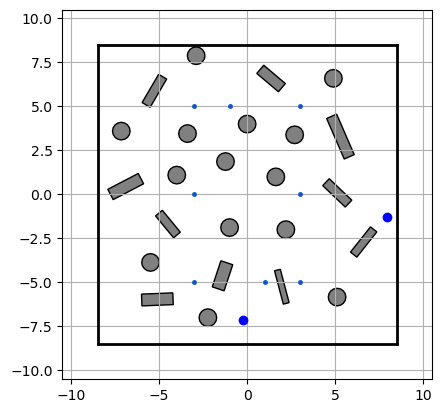

In [2]:
from SimEnv import get_edges, SimulationEnvironment_Scenario2, SimulationEnvironment_Scenario6, \
    SimulationEnvironment_CubeCollection, SimulationEnvironment_Warehouse, SimulationEnvironment_CA,SimulationEnvironment_Unmaze,\
        RRTStar
import networkx as nx
import numpy as np
import timeit
env=SimulationEnvironment_CubeCollection()
env.num_samples=20000
sample_p=env.sample_points()
ax=env.display_environment(show=0)
# ax.plot([p[0] for p in sample_p],[p[1] for p in sample_p],'bo')
ax.plot([p[0] for p in sample_p[:2]],[p[1] for p in sample_p[:2]],'bo')
print("slow",timeit.timeit('[env._is_line_collision((sample_p[0+i*2],sample_p[1+i*2])) for i in range(10000)]', globals=globals(), number=1))
env.build_tree()
# env._is_line_collisionSTR((sample_p[0],sample_p[1]))
timeit.timeit('[env._is_line_collisionSTR((sample_p[0+i*2],sample_p[1+i*2])) for i in range(10000)]', globals=globals(), number=1)


In [3]:
import numpy as np
np.all([True,False,True])

False

In [20]:
import numpy as np
import timeit
A=np.random.randn(4,4)
# B=np.random.randn(1000000)
# C=np.sqrt(A**2+B**2)
# print(C.shape)
# C=[sqrt(a**2+b**2) for a,b in zip(A,B)]
print(A)
rows = np.array([0, 2])
cols = np.array([1, 3])
sub_matrix = A[np.ix_(rows, cols)]
print(sub_matrix)
print(sub_matrix.min())
# min_index = np.unravel_index(np.argmin(sub_matrix), sub_matrix.shape)
# print(np.argmin(sub_matrix),min_index)
# rows = rows[min_index[0]]
# cols = cols[min_index[1]]
# A=[(0,0),(1,1),(2,2)]
# B=[(0,1),(1,1),(2,7)]
# np.linalg.norm(np.array(A)-np.array(B),axis=1)
# C=[(0,1)]
# C=np.array(C).repeat(3,axis=0)
# C
# print(np.argmin(A))
# A.sort()
# timeit.timeit('np.sqrt(A**2+B**2)', globals=globals(), number=1000)

[[ 0.33037345  0.22985235  1.20566304 -1.22654586]
 [ 1.25655332  0.1252276  -0.3641919  -2.62244914]
 [-2.51115367 -0.12505848 -1.11188029 -0.3288722 ]
 [-1.31213749 -0.13129893 -0.50828762 -0.41510224]]
[[ 0.22985235 -1.22654586]
 [-0.12505848 -0.3288722 ]]
-1.2265458594603973


In [3]:
import numpy as np
np.min([np.inf,np.inf])==np.inf



True